# What the regions have to tell each other: a multi-regional recurrent network model of fixation-locked population dynamics in BLA, ACCg, dmPFC and OFC

*Chapter notebook: Introduction · Methods · Results · Discussion. Task 04 of the final mRNN
series. Reads tasks 01–03; fits nothing.*

The population chapter established that the three fixation types — the partner's face
during an interactive period, the same face during a non-interactive period, and an object —
occupy separated states in all four recorded areas, and that the interactive-face state is
the compact, low-dimensional one. This chapter asks how those population trajectories are
*generated*: can each area produce its own trajectories from its own recurrence, or do the
areas need each other, and if so, what has to pass between them, through how many
dimensions, and for which fixation type does it matter most?

The tool is a multi-regional recurrent neural network (mRNN) with one recurrent block per
area, fitted to the four areas' trial-averaged PC trajectories. The method is to **constrain
and refit** rather than to interpret one fitted circuit: a constraint the data tolerate is
a statement about the data, a constraint they do not is a statement about what the
trajectories require.

| Figure | Question it answers |
|---|---|
| 1 | What is fitted, with what model, and what is the ceiling every fit is read against? |
| 2, 3 | Does a region need the network to reproduce its own trajectories? |
| 4 | Which connections carry that — inter-regional pathways, or a region's own recurrence? |
| 5 | How narrow can each kind of connection be? |
| 6 | Does narrowing a route cost one fixation type more than the others? |
| 7 | The selected network, refitted ten times: what did every constraint cost each fixation type? |
| 8 | Does any particular pair of regions carry the fit, and what does a lesion do to the local dynamics? |
| 9 | What does each fixation type's flow look like, and where does the trajectory run through it? |
| 10 | Which dynamical properties separate interactive face, in every fit? |
| 11 | What does a lesion do to each fixation type's trajectory? |

Regenerate with `conda run -n gaze_processing python notebooks/mrnn_chapter/_build_04_chapter.py`,
then execute with nbconvert (see the folder README). The task notebooks `01_ladder`,
`02_rank_grid`, `02b_bottleneck_properties` and `03_ensemble` hold every control and
supplementary panel this chapter summarises.

In [1]:
from __future__ import annotations

from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml
from IPython.display import Image, Markdown, display

repo_root = Path.cwd()
if not (repo_root / "src").exists():
    repo_root = next(parent for parent in Path.cwd().parents if (parent / "src").exists())
if str(repo_root / "src") not in sys.path:
    sys.path.insert(0, str(repo_root / "src"))

from dal_monte_2022_analysis.config.load import load_config
from dal_monte_2022_analysis.ephys.analysis import fixation_mrnn_audit as audit
from dal_monte_2022_analysis.ephys.analysis import fixation_mrnn_chapter as ch
from dal_monte_2022_analysis.ephys.analysis import fixation_mrnn_ensemble as ens
from dal_monte_2022_analysis.ephys.analysis import fixation_mrnn_synthesis as syn
from dal_monte_2022_analysis.ephys.modeling.fixation_mrnn_analysis import replay_fixation_mrnn_run
from dal_monte_2022_analysis.ephys.plotting import fixation_mrnn_chapter as cviz
from dal_monte_2022_analysis.ephys.plotting import fixation_mrnn_ensemble as eviz
from dal_monte_2022_analysis.ephys.plotting.thesis_common import (
    CONDITION_SHORT_LABELS, REGION_LABELS, ThesisFigureSettings, apply_thesis_plot_style,
    figure_to_png_bytes, save_thesis_figure,
)

DATASET_CFG_PATH = repo_root / "configs" / "dataset.yaml"
apply_thesis_plot_style(load_config(repo_root / "configs" / "plotting.yaml"))
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)

ROOTS = ch.final_roots(DATASET_CFG_PATH)
TASK_ROOT = ROOTS["04_chapter"]
FIGURE_DIR = syn.resolve_output_dir(DATASET_CFG_PATH, scope="final_04_chapter")
FIGURES = ThesisFigureSettings(output_dir=FIGURE_DIR)

BASE = yaml.safe_load((ROOTS["series"] / "base_model.yaml").read_text())
HIDDEN_UNITS = int(BASE["hidden_units"])
REGION_ORDER = tuple(BASE["region_order"])
RANKS = (1, 2, 3, 5, 10)
ADEQUATE_BAR = 0.98
TRACE_REGION = "bla"
SELECTED = yaml.safe_load((ROOTS["02_rank_grid"] / "selected_bottleneck.yaml").read_text())
SELECTED_ARM = "selected: within 1, inter-regional 10"
ARMS = {"dense": ROOTS["01_ladder"] / "full", "constrained": ROOTS["03_ensemble"] / f"ensemble_{SELECTED['label']}"}

T = ch.load_final_tables(ROOTS, hidden_units=HIDDEN_UNITS)
COND = CONDITION_SHORT_LABELS


def figure(fig, stem: str, caption: str) -> None:
    save_thesis_figure(fig, FIGURES, stem)
    display(Image(data=figure_to_png_bytes(fig, dpi=190)))
    display(Markdown(caption))
    plt.close(fig)


def cached(name: str, build):
    path = TASK_ROOT / "tables" / f"{name}.csv"
    if path.exists() and path.stat().st_size > 1:
        frame = pd.read_csv(path)
        if "seed" in frame.columns:
            frame["seed"] = frame["seed"].astype(str)
        return frame
    frame = build()
    if frame is not None and len(frame):
        path.parent.mkdir(parents=True, exist_ok=True)
        frame.to_csv(path, index=False)
    return frame


def md(text: str) -> None:
    display(Markdown(text))


def show_tests(table: pd.DataFrame, columns) -> None:
    """The contrast table behind a figure's marks, with the fixation-type names shortened."""
    out = table.copy()
    for column in ("a", "b"):
        if column in out:
            out[column] = out[column].map(lambda v: COND.get(v, v))
    display(out[[c for c in columns if c in out.columns]].round(5))


# Unit counts per region, read from the fitted target rather than retyped.
_replay = replay_fixation_mrnn_run(audit.seed_run_dirs(ROOTS["01_ladder"] / "full")[0], device="cpu")
UNITS = {region: int(np.asarray(array).shape[-1])
         for region, array in _replay["checkpoint"]["pc_reconstructed_raw_by_region"].items()}
N_COMPONENTS = int(np.asarray(_replay["checkpoint"]["target_by_region"][REGION_ORDER[0]]).shape[-1])
N_BINS = int(np.asarray(_replay["checkpoint"]["target_by_region"][REGION_ORDER[0]]).shape[1])
del _replay

# The long tables every cost figure and its tests read.
FIT_LONG = ch.constraint_fit_long(T)                 # arm, seed, condition, r2_vs_ceiling, r2 (regions pooled)
COST = ch.cost_per_seed_from_long(FIT_LONG)          # + cost, unexplained_ratio against the dense mean
MARGINAL_LONG = ch.marginal_fit_long(T)              # both marginals, arm = "<side> rank <r>"
MARGINAL_COST = ch.cost_per_seed_from_long(MARGINAL_LONG)

print("tables loaded:", ", ".join(sorted(T)))
print("units per region:", UNITS, "| components per region:", N_COMPONENTS, "| bins:", N_BINS)
print("selected bottleneck:", SELECTED["label"], "| figures →", FIGURE_DIR)

tables loaded: agreement_battery, band_recovery, condition_similarity, dense_fit, ensemble_fit, fit_cost_by_condition, fixed_points_points, fixed_points_summary, grid_fit, jacobian_along_trajectory, ladder_fit, lesion_battery, lesion_dynamics, lesion_ranking_agreement, lesion_ranking_by_condition, ordering_consistency, region_state_properties, similarity_summary
units per region: {'ofc': 241, 'bla': 537, 'dmpfc': 187, 'accg': 236} | components per region: 42 | bins: 100
selected bottleneck: w1_c10 | figures → /gpfs/milgram/pi/chang/pg496/repositories/local_data/dal_monte_2022/analysis_outputs/ephys/modeling/fixation_mrnn/plots/final_04_chapter


---

## 1. Introduction

### 1.1 The question

Four areas of the primate social brain — the basolateral amygdala (BLA), the gyrus of the
anterior cingulate cortex (ACCg), dorsomedial prefrontal cortex (dmPFC) and orbitofrontal
cortex (OFC) — were recorded while a monkey looked freely at a partner. The previous
chapters showed, first, that single units in every area distinguish the three kinds of
fixation the monkey makes (the partner's face during an interactive period, the same face
during a non-interactive period, an object), and second, that at the population level the
three fixation types occupy separated states in every area, separated mainly by a static
offset, with the two face conditions sharing a time-locked dynamic that neither shares with
object, and with the interactive-face state being the most compact and lowest-dimensional
of the three.

Those are descriptions of what each area's population *does* around a fixation. They say
nothing about how it comes to do it. The peri-fixation trajectory of BLA could be generated
by BLA's own recurrent circuitry, given a signal that says which kind of fixation is under
way; or it could be a trajectory BLA can only produce because ACCg, dmPFC and OFC are
feeding it structure it cannot generate alone. The same holds for every area. And if the
areas do need each other, there are further questions: is it the connections *between*
areas or the recurrence *within* an area that carries the trajectories; how many dimensions
must pass between two areas for the trajectories to survive; and is any of this different
for the interactive face — the fixation type whose population state the previous chapter
found to be special?

### 1.2 Why a fitted recurrent network, and what it can and cannot say

A multi-regional recurrent neural network (mRNN) is a generative hypothesis about exactly
this. It has one block of recurrently connected units per area, all-to-all connections
between blocks, a constant input that says which fixation type is under way, and a linear
readout from each block onto that area's population trajectory. Once fitted, it is a
mechanistic candidate: a set of coupled dynamical systems that reproduces what was recorded.

The obvious use of such a model — fit it once, then read its connection weights as a
circuit diagram — does not work here, and the chapter is built around that fact. The
model has about as many free parameters as there are numbers to fit, and the rebuild's
audit (task 06 of the `mrnn_thesis` series) established that independently seeded fits of
the same architecture reproduce the data equally well while agreeing about their weights,
their eigenspectra and their state geometry no better than untrained networks of the same
architecture agree. The circuit is not identifiable from these data.

What *is* identifiable is what the data tolerate. If a region fitted alone reproduces its
trajectories as well as it does inside the network, the network was not needed; if it does
not, the shortfall is what the network supplies, and where in the trajectory the shortfall
sits says what kind of signal that is. If every inter-regional block can be forced through
one dimension without loss, one dimension is all the areas have to tell each other; if the
fit collapses, it is not. These are statements about the trajectories, checked by whether a
model can still produce them under a stated restriction, and they do not depend on which
of the many equivalent circuits the optimiser happened to find. The second class of claim
that survives non-identifiability is a *within-model contrast*: a property computed inside
one fit and compared across fixation types, and then checked across ten independent fits.
Whether interactive face runs a slower, smaller trajectory than the other two is such a
contrast; which pathway carries it is not.

### 1.3 What this chapter finds

- **Every area needs the network to reproduce its own trajectories.** Fitted alone, each
  area falls short of its own ceiling; each climbs toward it as other areas are attached.
  What the network supplies is the fast structure of the trajectory — the 10–20 Hz band —
  which a region alone leaves two-thirds unreproduced (Figures 2, 3).
- **The inter-regional pathways carry the fit; a region's own recurrence barely does.**
  Removing every inter-regional connection costs about eight times more than reducing
  every region's own recurrent block to rank one (Figure 4).
- **A region's own recurrence can be one-dimensional; the pathways between regions
  cannot.** Rank 1 on every within-region block costs almost nothing; rank 1 on every
  inter-regional block costs most of what removing them costs, and about ten dimensions
  per pathway are needed before the cost becomes small (Figure 5).
- **Every constraint costs interactive face the most,** and the inter-regional bottleneck
  widens the gap (Figures 6, 7). In the selected network, refitted ten times, interactive
  face pays a third more than either other fixation type, and the widening of the gap is
  significant for every constraint in the chapter.
- **No particular pair of regions carries the fit.** Silencing any pair is catastrophic
  for a network this finely tuned, but no pair's share of the damage differs from one
  sixth, and the ten fits do not agree on which pair matters most. What a pair lesion does
  to the network's local dynamics is the same in every region, and largest for
  interactive face (Figure 8).
- **Interactive face has a dynamical signature every fit reproduces:** the smallest,
  slowest, lowest-dimensional trajectory, threading the most locally expansive part of the
  flow, and the one fixation type whose trajectory a pair lesion does not shrink
  (Figures 9–11). The wiring is not reproducible; the dynamics of this state are.

---

## 2. Methods

Presented in the order the results use them.

### 2.1 Data and target

The data are the same trial-averaged peri-fixation firing rates the population chapter
used: 10 ms bins, Gaussian-smoothed at $\sigma = 20$ ms before averaging, over a window of
$-500$ to $+500$ ms around fixation onset ($T = 100$ bins), for every unit that has an
average for all three fixation types. Interactive and non-interactive face come from the
interactive-state-split averages; object comes from the unsplit average, so it is not
matched for interactive state (see §4.6). Units are grouped by area (unit counts are
displayed under Figure 1).

The model is not asked to reproduce every unit. Each area's units are reduced by principal
component analysis fitted on the pooled fixation-type × time average (the same
concatenated fit the population chapter uses, so the condition offsets are kept), and the
target for area $r$ is the matrix of the first $K$ PC scores over time for each fixation
type: a $3 \times T \times K$ tensor. $K = 42$ is the smallest number of components that
reaches 95% of the variance in every area. Scores are divided by a single scale pooled over
all four areas, so the four targets are on one footing without changing their relative
sizes. Four areas × three fixation types × 100 bins × 42 components gives **50,400 target
numbers**. Throughout, a **region × fixation-type combination** means one area's target
for one fixation type: a $T \times K$ block, of which there are twelve.

### 2.2 The noise ceiling

A fit cannot legitimately reproduce more of a trial average than the average itself is
reliable for, so every fit is read against a **ceiling** computed the way the fit is scored
(Figure 1d). For each unit and fixation type the trials are split at random into two halves,
each half is averaged through the same pipeline as the target, and this is repeated for 25
random halvings and averaged, giving two independent half-averages per unit. Both halves of
every unit in an area are projected onto the *same* PCA basis the model is fitted on, and
centred per component over the pooled fixation-type × time trajectory, exactly as $R^2$ is
centred. For each region × fixation-type combination the two halves are then correlated over
the whole trajectory — every component and every bin at once, so the leading components
weigh in proportion to their variance, as they do in $R^2$ — and the Spearman–Brown
correction $2r / (1 + r)$ turns the split-half correlation into the reliability of the full
average, which is the $R^2$ a perfect model could reach. The ceilings sit at 0.983–0.998;
the same computation on Gaussian half-matrices, the noise control, sits at $\pm 0.01$, which
is why nothing below is read more finely than that.

### 2.3 The model

Area $r$ is a block of $n = 40$ units with state $h_r(t) \in \mathbb{R}^{40}$; the network
state $h(t)$ stacks the four blocks. The update is

$$h(t+1) = \tanh\!\left(W\,h(t) + W_{\mathrm{in}}\,u_c + b\right), \qquad
\hat y_r(t) = C_r\,h_r(t) + d_r ,$$

where $W$ is the $160 \times 160$ recurrent matrix, made of sixteen $40 \times 40$
blocks — four **within-region** blocks $W_{rr}$ (an area's own recurrence) and twelve
**inter-regional** blocks $W_{rs}$ (the pathway from area $s$ into area $r$); $u_c$ is a
one-hot code for the fixation type, constant over the whole window, so the only thing that
distinguishes the three fixation types is a fixed input vector $W_{\mathrm{in}} u_c$ and the
trained initial state $h_c(0)$; and $C_r$, $d_r$ is a linear readout from area $r$'s block
onto its $K$ PC scores. There is no time-varying input: everything the trajectories do
after the first bin, the network has to do on its own.

Width was fixed at 40 units per area by the rebuild (`mrnn_thesis` task 06): with 42 PCs
read out of $n$ units, the achievable $R^2$ is capped by the target's spectrum truncated at
$n$, and 40 is the narrowest width whose cap sits above the ceiling. The same width and the
same readout are used in every fit of this chapter, so nothing below is a capacity effect.
The dense model has 33,448 trainable parameters, 0.66 per target number.

**Rank constraints.** A within-region block can be written as a product of two factors,
$W_{rr} = L_r R_r$ with $L_r \in \mathbb{R}^{40 \times r_w}$ and
$R_r \in \mathbb{R}^{r_w \times 40}$, so that an area's own recurrent drive passes through
$r_w$ numbers; and every inter-regional block as $W_{rs} = L_{rs} R_{rs}$ of rank $r_c$.
"Dense" means no factorisation. Because area $r$ receives one within-region block and three
inter-regional blocks, its total recurrent drive has rank at most $r_w + 3\,r_c$; the two
constraints are therefore never compared at equal rank but along their **marginals**, one
side squeezed while the other stays dense (§2.8).

### 2.4 The objective

Each region × fixation-type combination is scored by its **unexplained fraction**

$$u_{rc} = \frac{\lVert \hat y_{rc} - y_{rc}\rVert^2 + \lambda_1 \lVert \Delta\hat y_{rc} - \Delta y_{rc}\rVert^2 + \lambda_2 \lVert \Delta^2\hat y_{rc} - \Delta^2 y_{rc}\rVert^2}{\mathrm{SST}_{rc}},$$

the squared error on the trajectory plus first- and second-difference terms
($\lambda_1 = 1$, $\lambda_2 = 0.5$; these weight the fast structure that a pointwise error
on a smooth trajectory underweights), divided by the combination's total sum of squares
centred per component over the pooled fixation-type × time trajectory — the centring the
ceiling uses. The loss is the **maximum** over the twelve combinations, softened for
differentiability:

$$\mathcal{L} = \tau \log \sum_{r,c} \exp(u_{rc} / \tau), \qquad \tau = 0.01 .$$

The reason is the fixation types themselves. Interactive face has five times the trials of
the other two, hence the quietest average, half their variance and the least
high-frequency power; an objective that sums absolute errors weights it in inverse
proportion to how well it was measured, and any fixed re-weighting simply chooses which
fixation type is sacrificed. Under the minimax objective the optimiser works on whichever
combination is worst, so the twelve degrade together when capacity is removed, no area
dominates by unit count, and "every fixation type reaches the ceiling" is a property of
the objective rather than a hope. Convergence and adequacy are the same curve.

### 2.5 Training

Adam, learning rate $3 \times 10^{-4}$ on a cosine schedule to 1% of its start, gradient
norm clipped at 0.05, 100,000 iterations of full-batch gradient descent on the three
fixation-type trajectories, tanh units, recurrent weights initialised to spectral radius 1.1,
initial states trained per fixation type. This is the only recipe in the rebuild's protocol
sweep (`mrnn_thesis` task 00) with zero failures across seeds and with the final iterate
equal to the best. The best iterate is saved and is what every analysis reads.

### 2.6 Scoring a fit

A fit is scored on every region × fixation-type combination by $R^2$ against that
combination's ceiling, with $R^2$ centred as the ceiling is. Where a single number is
needed for a fit it is the **worst combination** — the quantity the objective optimised,
and the one that says whether *every* fixation type in *every* area was reproduced. Where
regions are pooled, a fit's score for a fixation type is the mean over its four areas. The
only place a threshold enters is the selection of the bottlenecked model (§2.8), where a
worst fixation type at or above 0.98 of the ceiling is taken as adequate; 0.98 is the
tightest bar the ceiling's own error supports, and it is a selection rule, not a claim.

### 2.7 The ladder

Every non-empty subset of the four areas is fitted from scratch: four singles, six pairs,
four triples and the full network, five seeds each (ten for the full network, which is also
the dense reference for everything below). A subset fit contains only the blocks of its
members, so an area fitted alone is driven only by its own recurrence and the fixation-type
input. The target builder fits each area's PCA on its own units and pools the normalisation
scale over all four recorded areas, so **an area's target is bit-identical at every rung**
(verified to $\max|\Delta| = 0$); width and readout are identical too, so any gain up the
ladder is dynamical. Each area is then scored on its own trajectories at each rung: alone,
in the three pairs that contain it (averaged), in the three triples (averaged), and in the
full network.

To say *what* the network supplies, each fit's residual is also scored per frequency band:
the fraction of the target's power in 0–5, 5–10, 10–20 and 20–50 Hz that the fit leaves
unreproduced (10 ms bins, so 50 Hz is Nyquist).

The single-region rung is also the network with every inter-regional connection removed:
without cross blocks the areas do not interact, so four independent single-area fits at a
seed are that architecture, and pooling them per seed gives it the same regions-pooled,
per-seed score every other constraint has.

### 2.8 The rank grid

Every pair $(r_w, r_c) \in \{1, 2, 3, 5, 10\}^2$ is refitted from scratch, five seeds each
(125 fits), plus the two **marginals** — $(\text{dense}, r_c)$ and $(r_w, \text{dense})$ —
for another fifty. The dense corner is the ladder's full network. Each configuration is
summarised by its **worst fixation type**: regions pooled per seed, the minimum over the
three fixation types, averaged over seeds. The **selected model** is the grid configuration
with the lowest total drive rank $r_w + 3 r_c$ whose worst fixation type is at or above 0.98
of the ceiling, ties to the lower inter-regional rank; marginals are excluded from selection
because the selected model is meant to constrain both sides.

### 2.9 The ensemble

The selected model is fitted ten more times with fresh seeds and read against the ten dense
fits. **Cost** of a constraint to a fixation type is the dense mean minus the constrained
fit's regions-pooled ceiling-relative $R^2$, one value per constrained seed. The same
computation is applied to the ladder's single rung and to the grid's marginals, so every
constraint in the chapter is costed on one footing (Figure 7). The scale-free reading,
reported alongside, is the ratio of unexplained variance, constrained over dense.

### 2.10 Lesions

In each converged fit of both arms, blocks are silenced and the fit is rerun: every
directed pathway (12), every region pair in both directions (6), every within-region block
(4), and every set of pathways into and out of one region (4, "isolation"), each beside a
control that silences the same number of randomly chosen weights anywhere in the network
(five draws, averaged). Damage is the added squared error, reported in units of the
target's total variance so that a fixation type with half the variance is not read as
"less affected" for that reason alone; a pair's **share** is its damage over the summed
damage of the six pairs within a fit. Whether the ten fits agree on *which* lesions matter
is Kendall's $\tau$ between their damage rankings, read against a permutation null.

### 2.11 Dynamics

Because the input is constant within a fixation type, each fixation type turns the fitted
network into an **autonomous map**, $h \mapsto F_c(h) = \tanh(W h + W_{\mathrm{in}} u_c + b)$.
Three views of it are used, each computed within one fit and compared across fixation
types, then checked across the ten fits.

*Fixed points* of $F_c$ are found by minimising $\tfrac12\lVert F_c(h) - h\rVert^2$ from
48 starts — states the trajectory visits and noisy copies of them — polished by Newton's
method, clustered, and linearised (Jacobian $\mathrm{diag}(1 - h^{*2})\,W$, with the bias
included). Reported per fixation type: how many, how far the trajectory's end is from the
nearest one (in units of the pooled state extent), the speed at the trajectory's end, and
the nearest fixed point's stability.

*Flow fields* are pictures of $F_c$ itself. The plane is spanned by the two leading
principal axes of the hidden-state trajectories $h(t)$ pooled over the three fixation types
(300 states in 160 dimensions), so the three panels share one plane and the percentages on
the axes are the share of hidden-state variance each axis carries. At every point $h$ of a
grid in that plane the one-step displacement $F_c(h) - h$ of the full nonlinear map is
evaluated; its direction, projected into the plane, is drawn as an arrow, and its magnitude
— the local speed of the flow — as the background. **Nothing is averaged over time**: the
map is the same at every bin because the input is constant, so the field is a property of
the fixation type's dynamics, not of any moment in the trial; the linearisation is not used
here at all. The coloured line is the trajectory the fitted network actually runs for that
fixation type, projected into the same plane; it starts at the trained initial state, which
is the first bin of the window (495 ms before fixation onset, drawn as a circle) and ends at
the last bin (495 ms after onset, drawn as a square), with time running light to dark. Stars
are the map's fixed points, filled if stable. Two cautions: the plane is two of 160
dimensions, so the arrows are projections and the trajectory can appear to cross them where
its motion is out of plane; and a region's own flow field (task 03) clamps the drive it
receives from the other three regions at its time average for that fixation type — the one
place a time average enters, and an approximation stated on those figures.

*Local linearisation along the trajectory*: the Jacobian $\mathrm{diag}(1 - h(t{+}1)^2)\,W$ at
every state the trajectory visits, for the whole network and for each region's own block
(its intrinsic dynamics with input held fixed). Reported: the largest eigenvalue modulus
(above one, locally expanding) and how many modes expand.

### 2.12 What a lesion does to the local dynamics

Each pair lesion and each isolation is also read as a change in the dynamics rather than in
the fit. After the lesion the network is rerun, and three things are recorded per fixation
type: the extent of the lesioned trajectory relative to the intact one; and the
**eigenvalue spectrum** of the lesioned network's local linearisation at two places — at
the fixed point of the lesioned map nearest the end of its trajectory (found as in §2.11
with 16 starts), and along the lesioned trajectory (every fifth visited state, eigenvalues
pooled). Spectra are taken for each region's own block, $\mathrm{diag}(1 - h_r^2)\,W_{rr}$,
and for the whole network. The change in a spectrum is the **2-Wasserstein distance**
between the lesioned and the intact set of eigenvalues in the complex plane — the
root-mean-square displacement under the optimal one-to-one matching of the two sets, exact
for equal-size sets — so a lesion that moves every eigenvalue a little and one that moves
a few eigenvalues a lot are both scored by how far the spectrum moved. One property of the
selected model bears on this: with every within-region block at rank 1, a region's own
linearisation has a single non-zero eigenvalue, so at the region scope the distance
measures how that one mode moves, and the whole-network spectrum is the informative one.

### 2.13 Statistics and conventions

Every comparison the figures mark is one of three tests, chosen by what is paired.
*Between fixation types within one arm* the values are paired by fit (the same seed gives
all three fixation types), so the test is a **paired t-test**; where the unit is a fit ×
lesion, pairs are matched on both. *Between arms* (a constrained set of fits against the
dense set, or two constraints against each other) the fits are independent, so the test is
**Welch's t-test**. *Whether a constraint costs one fixation type more than another* is an
interaction — the cost is a dense mean minus a constrained value — and is tested as the
per-seed difference between the two fixation types' scores in the constrained fits against
the same difference in the dense fits, by Welch's t-test; a significant result means the
constraint widened the gap. A pair's share of lesion damage is tested against one sixth
with a one-sample t-test, and a lesion family's damage against its matched random control
with a paired t-test by fit.

Within each figure panel the p-values are **Holm-corrected**, and a comparison is marked at
$\alpha = 0.05$ (\* below 0.05, \*\* below 0.01, \*\*\* below 0.001) by a bar over the two
groups with the stars above it. **Only significant comparisons are marked**; an unmarked
pair was tested and did not reach significance. The number of fits per group is stated in
every caption; with five fits per group the tests are underpowered for small effects, so
the absence of a mark is never read as evidence of equality. Grouped comparisons between
fixation types are drawn as bars (mean, with the standard error of the mean as a capless
error bar) with every fit overlaid as a dot, and the y-axis starts at zero; where a single
group of fits is compared between arms, box plots (median, quartiles, whiskers to the full
range) with every fit as a dot; groups of forty or more values as violins with the quartiles
inside. Costs are always against the dense network. Per-fixation-type damage is never
expressed as a per-condition $R^2$, which would divide by each fixation type's own variance
and manufacture a difference between a half-variance condition and the other two (the
confound the rebuild's audit found). Where a claim rests on the ten fits agreeing, the
fraction of fits in which it holds is stated.

---

## 3. Results

### 3.1 What is fitted, with what, and how a fit is read

Figure 1 is the setup. Panel (a) is the data as the previous chapters saw it: every unit's
trial-averaged firing rate for the three fixation types. Panel (b) is what the model is
asked to reproduce: each area's trajectory through its own PC space, 42 components deep,
for each fixation type. Panel (c) is the network — four all-to-all recurrent blocks, one
per area, driven by a constant fixation-type input and read out block by block. Panel (d) is
the noise ceiling every fit is read against, and how it is measured. Figure 1b shows the
three ways the network is then constrained or damaged, which the rest of the chapter walks
through in order.

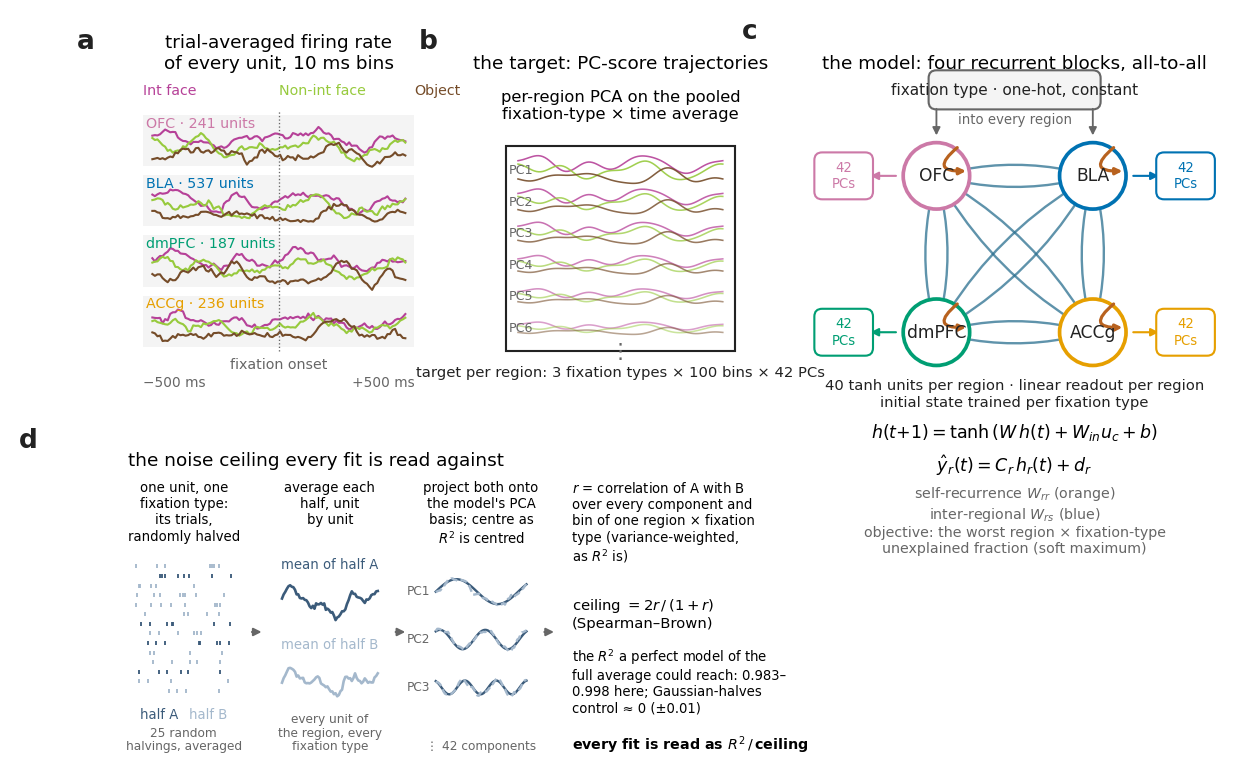

**Figure 1. What is fitted, with what, and the ceiling every fit is read against.** (a) Trial-averaged firing rates of every unit in the four areas for the three fixation types, 10 ms bins, −500 to +500 ms around fixation onset. (b) The target: each area's trajectory through its own PC space, 42 components, one trajectory per fixation type. (c) The multi-regional RNN: four blocks of 40 tanh units, all twelve inter-regional pathways (blue) and four within-region blocks (orange), a constant one-hot fixation-type input into every block, and a linear readout from each block onto its area's PC scores. The objective is the worst of the twelve region × fixation-type unexplained fractions. (d) The noise ceiling: each unit's trials are halved at random (25 halvings, averaged), each half is averaged, both halves are projected onto the model's own PCA basis and centred as $R^2$ is, the two are correlated over every component and bin of one region × fixation type, and the Spearman–Brown correction gives the reliability of the full average. Every fit is scored as $R^2$ / ceiling.

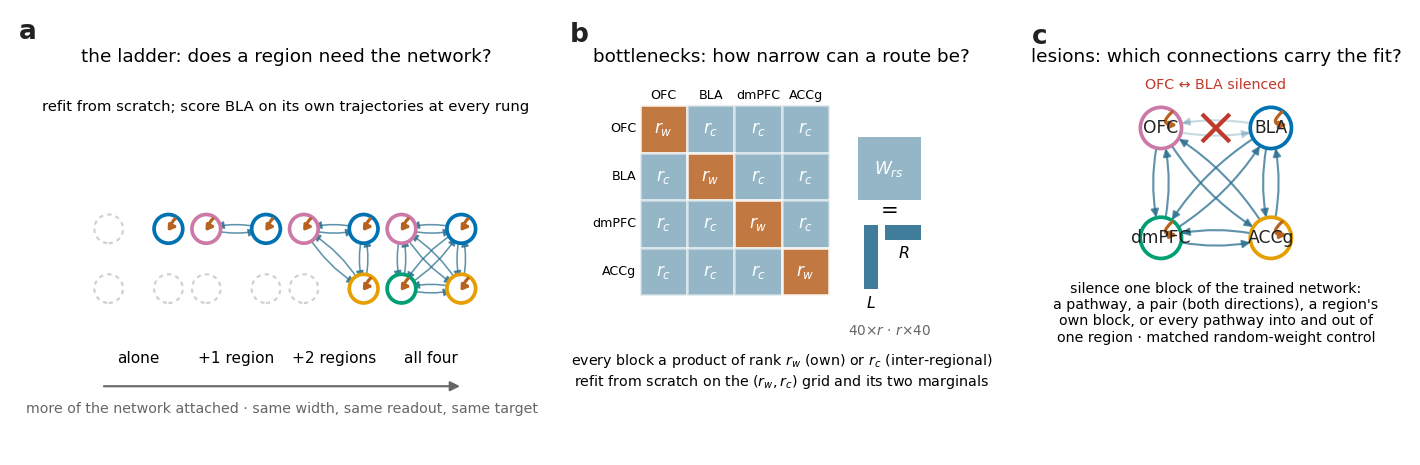

**Figure 1b. Three manipulations.** (a) The ladder: an area is fitted alone, in every pair, every triple and the full network, at the same width, readout and target, and scored on its own trajectories at every rung. (b) Rank bottlenecks: every within-region block is a product of rank $r_w$ and every inter-regional block a product of rank $r_c$, refitted from scratch over the grid and its two marginals. (c) Lesions: one block (or set of blocks) of the trained network is silenced and the damage read against a matched random-weight control.

Units per area: **OFC** 241, **BLA** 537, **dmPFC** 187, **ACCg** 236 · 1201 in total · 42 components per area · 100 bins · target of 50,400 numbers.

**The ceiling per region × fixation-type combination** (and pooled over fixation types, `all`):

condition,all,face_interactive,face_non_interactive,object
region,,,,
accg,0.9923,0.9934,0.9906,0.9935
bla,0.9964,0.9980,0.9960,0.9959
dmpfc,0.9853,0.9877,0.9834,0.9879
ofc,0.9911,0.9939,0.9879,0.9920


In [2]:
figure(cviz.plot_chapter_schematic(n_units_by_region=UNITS, n_components=N_COMPONENTS, hidden_units=HIDDEN_UNITS, n_bins=N_BINS),
       "fig01_schematic",
       "**Figure 1. What is fitted, with what, and the ceiling every fit is read against.** (a) Trial-averaged firing rates of every "
       "unit in the four areas for the three fixation types, 10 ms bins, −500 to +500 ms around fixation onset. (b) The target: each "
       f"area's trajectory through its own PC space, {N_COMPONENTS} components, one trajectory per fixation type. (c) The multi-regional "
       f"RNN: four blocks of {HIDDEN_UNITS} tanh units, all twelve inter-regional pathways (blue) and four within-region blocks (orange), "
       "a constant one-hot fixation-type input into every block, and a linear readout from each block onto its area's PC scores. The "
       "objective is the worst of the twelve region × fixation-type unexplained fractions. (d) The noise ceiling: each unit's trials "
       "are halved at random (25 halvings, averaged), each half is averaged, both halves are projected onto the model's own PCA basis "
       "and centred as $R^2$ is, the two are correlated over every component and bin of one region × fixation type, and the "
       "Spearman–Brown correction gives the reliability of the full average. Every fit is scored as $R^2$ / ceiling.")
figure(cviz.plot_manipulation_schematic(hidden_units=HIDDEN_UNITS), "fig01b_manipulations",
       "**Figure 1b. Three manipulations.** (a) The ladder: an area is fitted alone, in every pair, every triple and the full "
       "network, at the same width, readout and target, and scored on its own trajectories at every rung. (b) Rank bottlenecks: "
       "every within-region block is a product of rank $r_w$ and every inter-regional block a product of rank $r_c$, refitted from "
       "scratch over the grid and its two marginals. (c) Lesions: one block (or set of blocks) of the trained network is silenced and "
       "the damage read against a matched random-weight control.")
md(f"Units per area: " + ", ".join(f"**{REGION_LABELS[r]}** {UNITS[r]}" for r in REGION_ORDER if UNITS.get(r))
   + f" · {sum(v for v in UNITS.values() if v)} in total · {N_COMPONENTS} components per area · {N_BINS} bins · "
   f"target of {3 * N_BINS * N_COMPONENTS * len(REGION_ORDER):,} numbers.")
md("**The ceiling per region × fixation-type combination** (and pooled over fixation types, `all`):")
display(pd.read_csv(ROOTS["series"] / "pc_space_ceiling_by_cell.csv").pivot(index="region", columns="condition", values="reliability").round(4))

The ceilings (table above) are 0.983–0.998 in every combination, so a model that reaches
them has reproduced everything in the average that is not measurement noise. The ceilings
differ between fixation types within an area by up to 0.005 — non-interactive face is the
lowest in every area — which is one reason every fit below is read against its own
combination's ceiling rather than a single number per area.

### 3.2 A region needs the network to reproduce its own trajectories

Figure 2 shows the result the ladder was built for, in one area. BLA's reconstructed PC
trajectories are drawn for the three fixation types at each rung: fitted alone, averaged
over the three pairs that contain BLA, averaged over the three triples, and in the full
network. Three components are overlaid in every panel, each on its own scale: the leading
one, which carries the most variance, and the two among the first ten with the largest gain
from the single rung to the full network (chosen on the mean gain over the three fixation
types, so no fixation type picks its own). The target is the prominent trace — thick, in
three shades of the fixation type's colour — and the reconstruction the thin grey line in
the same order, so the eye follows the expected trajectory and reads the fit as how closely
the grey line tracks it; the number beside each panel is the component's $R^2$, averaged
over the fits at the rung.

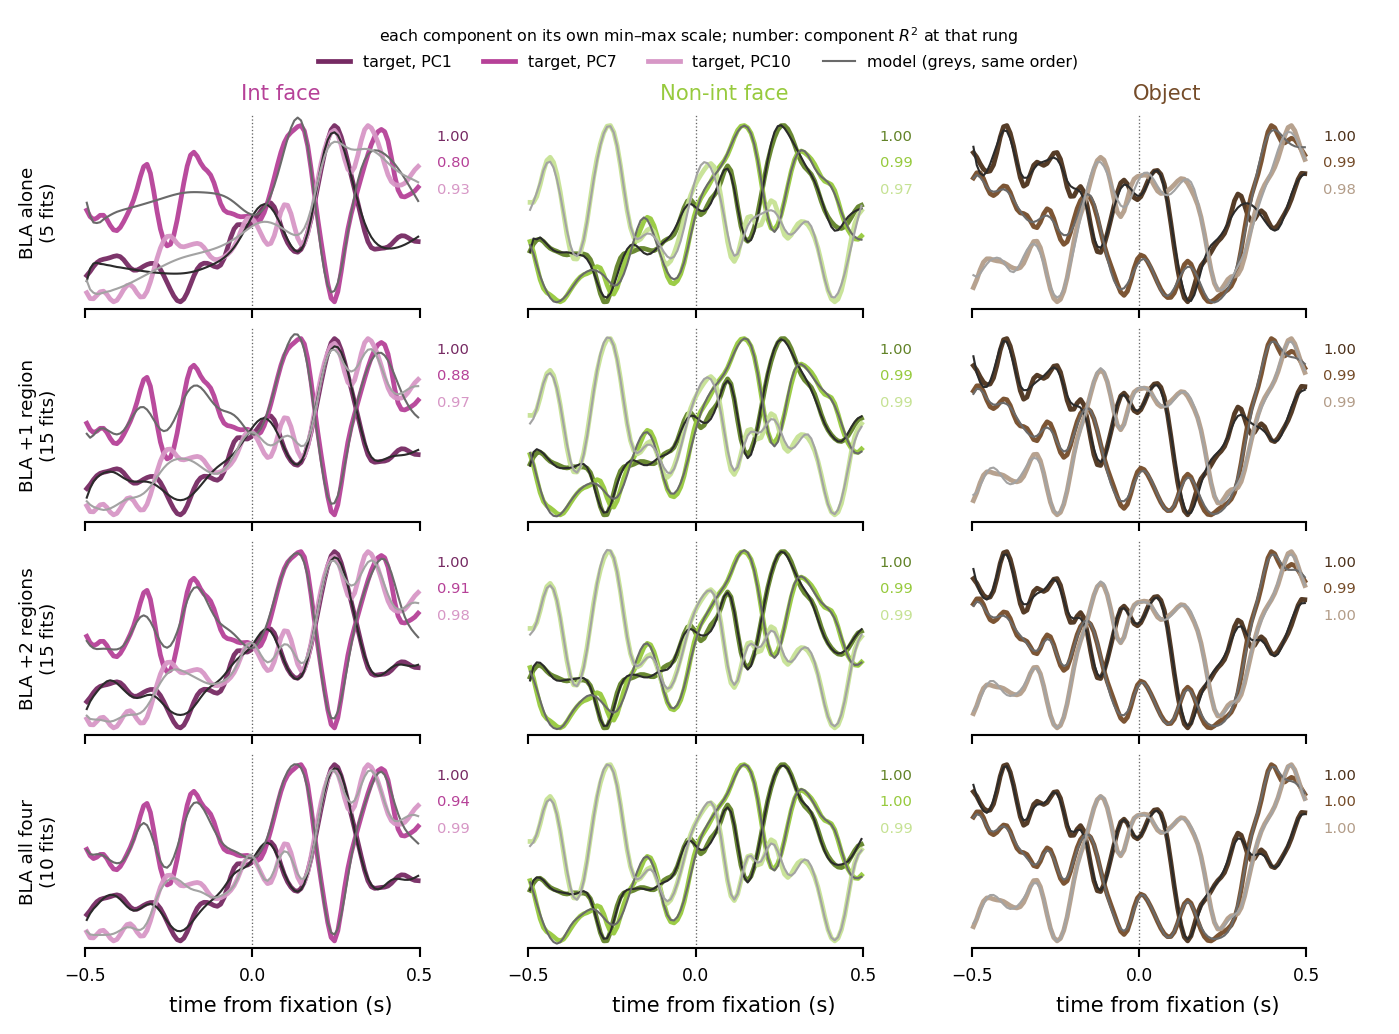

**Figure 2. BLA reproduces its own trajectories only with the network attached.** Rows: BLA fitted alone (5 fits), in the three pairs that contain it (15 fits, averaged), in the three triples (15 fits, averaged), and in the full network (10 fits). Columns: fixation type. Three components are overlaid in each panel, PC1, PC7, PC10 (dark to light), each rescaled to its own target range so all three fill the panel. Thick coloured lines: the target, identical at every rung. Thin grey lines, same order: the reconstruction averaged over the fits at that rung. Numbers: each component's $R^2$, mean over the fits, in the target's shades. Fixation onset is the dotted line.

**Component $R^2$ per component and rung** (mean over the fits at the rung):

,alone,+1 region,+2 regions,all four
"(Int face, PC1)",0.996,0.998,0.998,0.999
"(Int face, PC7)",0.802,0.881,0.911,0.941
"(Int face, PC10)",0.926,0.967,0.979,0.987
"(Non-int face, PC1)",0.999,0.999,1.000,1.000
"(Non-int face, PC7)",0.993,0.994,0.995,0.996
"(Non-int face, PC10)",0.975,0.986,0.993,0.995
"(Object, PC1)",0.999,0.999,1.000,1.000
"(Object, PC7)",0.991,0.993,0.995,0.997
"(Object, PC10)",0.983,0.993,0.996,0.998


**Which components gain from the network** (mean over the three fixation types, first ten components; variance share of each component in BLA's target):

,variance_share,r2_rung0,r2_rung3,gain
index,,,,
PC1,0.298,0.998,0.999,0.001
PC2,0.205,0.993,0.998,0.005
PC3,0.047,0.985,0.996,0.011
PC4,0.042,0.984,0.996,0.013
PC5,0.034,0.974,0.988,0.015
PC6,0.028,0.977,0.994,0.016
PC7,0.027,0.928,0.978,0.050
PC8,0.023,0.970,0.987,0.017
PC9,0.021,0.969,0.990,0.021


In [3]:
gain = cached(f"ladder_component_gain_{TRACE_REGION}", lambda: ch.ladder_component_gain(T["ladder_fit"], region=TRACE_REGION))
components = ch.select_trace_components(gain)
traces = cached(f"ladder_traces_{TRACE_REGION}", lambda: ch.ladder_region_traces(T["ladder_fit"], region=TRACE_REGION, indices=components))
n_fits = traces.groupby("n_partners")["n_fits"].first().to_dict()
figure(cviz.plot_ladder_traces(traces, region=TRACE_REGION, n_fits_by_rung=n_fits), f"fig02_ladder_traces_{TRACE_REGION}",
       f"**Figure 2. {REGION_LABELS[TRACE_REGION]} reproduces its own trajectories only with the network attached.** Rows: "
       f"{REGION_LABELS[TRACE_REGION]} fitted alone ({n_fits.get(0)} fits), in the three pairs that contain it ({n_fits.get(1)} fits, "
       f"averaged), in the three triples ({n_fits.get(2)} fits, averaged), and in the full network ({n_fits.get(3)} fits). Columns: "
       "fixation type. Three components are overlaid in each panel, " + ", ".join(f"PC{k + 1}" for k in components)
       + " (dark to light), each rescaled to its own target range so all three fill the panel. Thick coloured lines: the target, "
       "identical at every rung. Thin grey lines, same order: the reconstruction averaged over the fits at that rung. Numbers: each "
       "component's $R^2$, mean over the fits, in the target's shades. Fixation onset is the dotted line.")
lane_r2 = traces.groupby(["condition", "index", "n_partners"])["r2_mean"].first().unstack("n_partners")
lane_r2.index = [(COND[c], f"PC{k + 1}") for c, k in lane_r2.index]
lane_r2.columns = [ch.RUNG_LABELS.get(c, c) for c in lane_r2.columns]
md("**Component $R^2$ per component and rung** (mean over the fits at the rung):")
display(lane_r2.round(3))
md("**Which components gain from the network** (mean over the three fixation types, first ten components; "
   f"variance share of each component in {REGION_LABELS[TRACE_REGION]}'s target):")
display(gain[gain["index"] < 10].groupby("index")[["variance_share", "r2_rung0", "r2_rung3", "gain"]].mean().rename(index=lambda k: f"PC{k + 1}").round(3))

The leading component is reproduced by BLA alone — its $R^2$ is 1.00 in every panel — and so,
nearly, is everything for non-interactive face and object: their components are at or above
0.97 at the bottom of the ladder and the grey model lines sit on the coloured targets. The
gain is concentrated in interactive face and in the mid-rank components. Alone, BLA
reproduces interactive face's seventh component at $R^2 = 0.80$ and its tenth at 0.93; with
one other area attached these rise to 0.88 and 0.97, with two to 0.91 and 0.98, and in the
full network to 0.94 and 0.99. In the interactive-face column the grey line moves onto the
target row by row; in the other two columns it was already there.

Figure 3 puts numbers on the whole ladder.

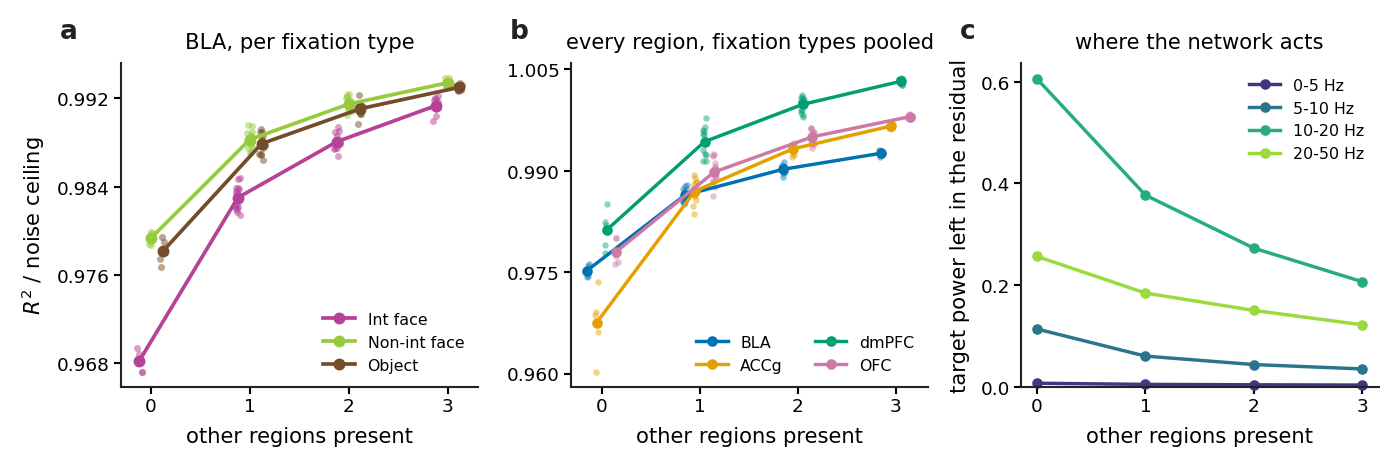

**Figure 3. The ladder in numbers.** (a) BLA's ceiling-relative $R^2$ per fixation type against the number of other areas present; small marks are individual fits (5 alone, 15 per pair rung, 15 per triple rung, 10 in the full network), large marks the rung mean. (b) The same for every area, fixation types pooled. (c) The fraction of the target's power the fit leaves unreproduced, per frequency band, areas and fixation types pooled: the slow band is reproduced alone, the 10–20 Hz band is what the network supplies.

**Ceiling-relative $R^2$ per area and rung** (mean over fits) and the gain from alone to the full network:

,alone,+1 region,+2 regions,all four,gain_alone_to_full
region,,,,,
ACCg,0.9675,0.9870,0.9932,0.9966,0.0290
BLA,0.9752,0.9864,0.9902,0.9926,0.0174
dmPFC,0.9812,0.9943,0.9998,1.0032,0.0220
OFC,0.9780,0.9898,0.9950,0.9980,0.0200


**Worst region × fixation-type combination per fit, by rung:**

,mean,min,max,count
rung,,,,
alone,0.9697,0.9536,0.9811,20
+1 region,0.9834,0.9802,0.9855,30
+2 regions,0.9885,0.9868,0.9905,20
all four,0.9913,0.9899,0.9922,10


**BLA per fixation type**:

,alone,+1 region,+2 regions,all four,gain
condition,,,,,
Int face,0.9682,0.9830,0.9881,0.9913,0.0232
Non-int face,0.9793,0.9883,0.9915,0.9934,0.0141
Object,0.9781,0.9879,0.9911,0.9930,0.0149


**Target power left in the residual**, per band and rung (areas pooled):

,alone,+1 region,+2 regions,all four
band,,,,
0-5 Hz,0.007,0.005,0.004,0.004
5-10 Hz,0.114,0.061,0.044,0.035
10-20 Hz,0.606,0.377,0.273,0.207
20-50 Hz,0.257,0.185,0.150,0.122


In [4]:
figure(cviz.plot_ladder_summary(T["ladder_fit"], T["band_recovery"], region=TRACE_REGION), "fig03_ladder_summary",
       f"**Figure 3. The ladder in numbers.** (a) {REGION_LABELS[TRACE_REGION]}'s ceiling-relative $R^2$ per fixation type against the "
       "number of other areas present; small marks are individual fits (5 alone, 15 per pair rung, 15 per triple rung, 10 in the full "
       "network), large marks the rung mean. (b) The same for every area, fixation types pooled. (c) The fraction of the target's "
       "power the fit leaves unreproduced, per frequency band, areas and fixation types pooled: the slow band is reproduced alone, the "
       "10–20 Hz band is what the network supplies.")
by_region = ch.ladder_by_region(T["ladder_fit"])
by_region.columns = [ch.RUNG_LABELS.get(c, c) if isinstance(c, (int, np.integer)) else c for c in by_region.columns]
md("**Ceiling-relative $R^2$ per area and rung** (mean over fits) and the gain from alone to the full network:")
display(by_region.rename(index=REGION_LABELS).round(4))
worst = ch.ladder_worst_cell(T["ladder_fit"], bar=ADEQUATE_BAR)
worst["rung"] = worst["n_partners"].map(ch.RUNG_LABELS)
md("**Worst region × fixation-type combination per fit, by rung:**")
display(worst.set_index("rung")[["mean", "min", "max", "count"]].round(4))
per_cond = ch.ladder_by_condition(T["ladder_fit"], region=TRACE_REGION).groupby(["condition", "n_partners"])["r2_vs_ceiling"].mean().unstack("n_partners")
per_cond.columns = [ch.RUNG_LABELS.get(c, c) for c in per_cond.columns]
per_cond["gain"] = per_cond["all four"] - per_cond["alone"]
md(f"**{REGION_LABELS[TRACE_REGION]} per fixation type**:")
display(per_cond.rename(index=COND).round(4))
band = ch.band_residual_by_rung(T["band_recovery"], T["ladder_fit"]).groupby(["band", "n_partners"])["residual_fraction"].mean().unstack("n_partners")
band.columns = [ch.RUNG_LABELS.get(c, c) for c in band.columns]
md("**Target power left in the residual**, per band and rung (areas pooled):")
display(band.loc[["0-5 Hz", "5-10 Hz", "10-20 Hz", "20-50 Hz"]].round(3))

**No area reproduces its own trajectories alone.** Fitted on its own, each area's
ceiling-relative $R^2$ is 0.967–0.981, and the worst region × fixation-type combination of a
single-area fit averages 0.970. Attaching one other area lifts every area to 0.986–0.994;
attaching two lifts it further; the full network reaches 0.993–1.003. The gain from alone
to the full network is 0.017 (BLA) to 0.029 (ACCg) of ceiling-relative $R^2$, against a
seed spread of about 0.001 at the top of the ladder. The slope is the same in all four
areas, so the network is something every area needs rather than something one area
supplies (the pair matrix in task 01 confirms that the gains do not separate by partner).

**Interactive face needs it most.** In BLA, interactive face climbs from 0.968 alone to
0.991 in the full network, a gain of 0.023, against 0.014–0.015 for the other two fixation
types; the same ordering holds in every area and at every rung (task 01, §8). At the
single rung, interactive face is the worst-fitted fixation type in every area.

**What the network supplies is the fast structure.** The 0–5 Hz band of the trajectory is
reproduced by an area alone (less than 1% of its power left in the residual at any rung).
The 10–20 Hz band is not: an area alone leaves 61% of that band's power unreproduced, and
the full network cuts it to 21%. The 5–10 and 20–50 Hz bands sit in between. So the
statement "a region needs the network" has a specific content: an area's own recurrence
generates the slow envelope of its trajectory, and the areas together generate its fast
structure — the part of the peri-fixation response the population chapter could not
address at all.

### 3.3 The inter-regional pathways carry the fit; a region's own recurrence barely does

Two kinds of connection could be what the ladder is measuring: the pathways between areas,
or the recurrence within each area that the network's input makes useful. Figure 4 removes
or squeezes each kind and costs it against the dense network: every inter-regional
connection removed (the single-region rung), every within-region block reduced to rank 1
with the pathways dense, and every pathway reduced to rank 1 with within-region recurrence
dense.

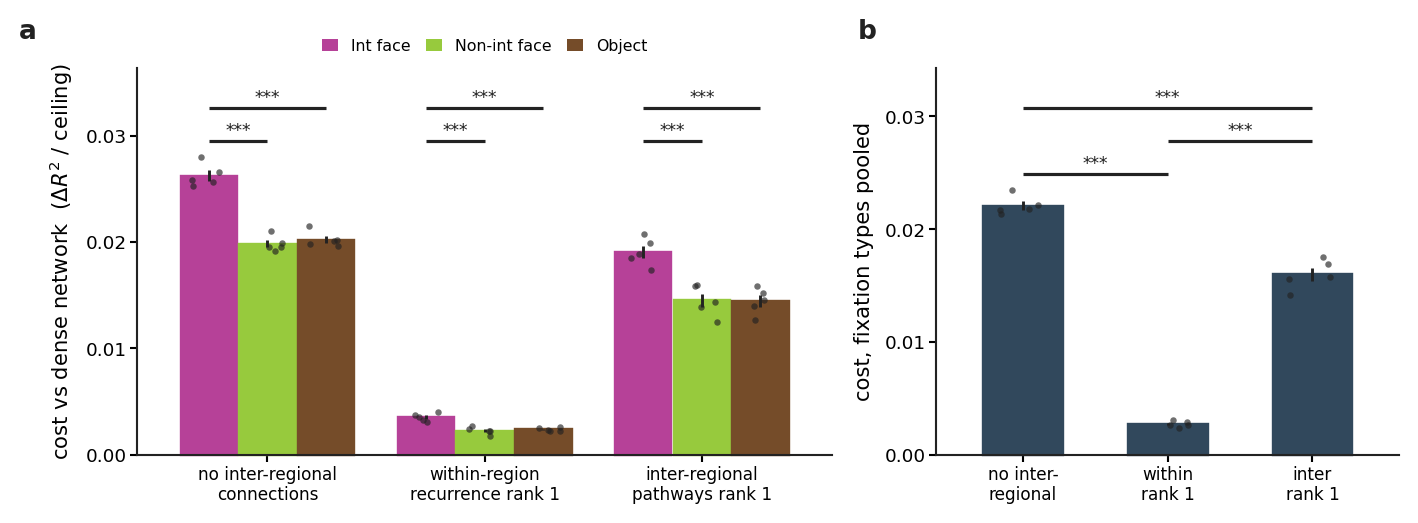

**Figure 4. Removing inter-regional connections costs far more than removing within-region recurrence.** (a) Cost against the ten dense fits, per fixation type, of three constraints (five fits each): every inter-regional connection removed, every within-region block reduced to rank 1 with the pathways dense, and every inter-regional pathway reduced to rank 1 with within-region recurrence dense. Bars: mean and SEM; dots: fits. Marks: the constraint widens the gap between the two fixation types (Welch's t on per-fit gaps against the ten dense fits, Holm-corrected within the panel). (b) The same cost pooled over fixation types, one value per fit; marks: Welch's t between constraints, Holm-corrected.

**Cost against the dense network** (Δ ceiling-relative $R^2$, regions pooled per fit; mean and sd over fits):

mean     std  count
arm                           condition                          
inter-regional rank 1         Int face      0.0190  0.0013      5
                              Non-int face  0.0145  0.0014      5
                              Object        0.0144  0.0012      5
no inter-regional connections Int face      0.0262  0.0011      5
                              Non-int face  0.0198  0.0007      5
                              Object        0.0202  0.0007      5
within-region rank 1          Int face      0.0035  0.0004      5
                              Non-int face  0.0022  0.0003      5
                              Object        0.0024  0.0002      5

**Tests behind panel (a)** — does the constraint widen the gap between interactive face and each other fixation type?

,arm,a,b,n_arm,n_reference,difference,statistic,p,p_holm,stars
0,no inter-regional connections,Int face,Non-int face,5,10,0.00642,34.58234,0.00000,0.00000,***
1,no inter-regional connections,Int face,Object,5,10,0.00602,26.49697,0.00000,0.00000,***
2,within-region rank 1,Int face,Non-int face,5,10,0.00128,11.92513,0.00000,0.00000,***
3,within-region rank 1,Int face,Object,5,10,0.00115,8.19582,0.00002,0.00002,***
4,inter-regional rank 1,Int face,Non-int face,5,10,0.00453,22.51957,0.00000,0.00000,***
5,inter-regional rank 1,Int face,Object,5,10,0.00460,25.15896,0.00000,0.00000,***


**Tests behind panel (b)** — Welch's t between constraints on the pooled cost:

,a,b,n_a,n_b,mean_a,mean_b,difference,statistic,p,p_holm,stars
0,no inter-regional connections,within-region rank 1,5,5,0.02209,0.00272,0.01938,48.50021,0.00000,0.00000,***
1,no inter-regional connections,inter-regional rank 1,5,5,0.02209,0.01599,0.00610,8.77960,0.00006,0.00006,***
2,inter-regional rank 1,within-region rank 1,5,5,0.01599,0.00272,0.01328,22.25056,0.00001,0.00002,***


In [5]:
ARCH = ["no inter-regional connections", "within-region rank 1", "inter-regional rank 1"]
gap4 = ch.gap_contrasts(FIT_LONG[FIT_LONG["arm"].isin(["dense"] + ARCH)], value="r2_vs_ceiling")
pooled = COST.groupby(["arm", "seed"])["cost"].mean().reset_index()
pooled4 = ch.welch_contrasts(pooled[pooled["arm"].isin(ARCH)], value="cost", group="arm",
                             pairs=[(ARCH[0], ARCH[1]), (ARCH[0], ARCH[2]), (ARCH[2], ARCH[1])])
figure(cviz.plot_architecture_cost(COST, gap4, pooled4, constraints=ARCH), "fig04_architecture_cost",
       "**Figure 4. Removing inter-regional connections costs far more than removing within-region recurrence.** (a) Cost against "
       "the ten dense fits, per fixation type, of three constraints (five fits each): every inter-regional connection removed, every "
       "within-region block reduced to rank 1 with the pathways dense, and every inter-regional pathway reduced to rank 1 with "
       "within-region recurrence dense. Bars: mean and SEM; dots: fits. Marks: the constraint widens the gap between the two "
       "fixation types (Welch's t on per-fit gaps against the ten dense fits, Holm-corrected within the panel). (b) The same cost "
       "pooled over fixation types, one value per fit; marks: Welch's t between constraints, Holm-corrected.")
md("**Cost against the dense network** (Δ ceiling-relative $R^2$, regions pooled per fit; mean and sd over fits):")
display(COST[COST["arm"].isin(ARCH)].assign(condition=COST["condition"].map(COND)).groupby(["arm", "condition"])["cost"].agg(["mean", "std", "count"]).round(4))
md("**Tests behind panel (a)** — does the constraint widen the gap between interactive face and each other fixation type?")
show_tests(gap4, ["arm", "a", "b", "n_arm", "n_reference", "difference", "statistic", "p", "p_holm", "stars"])
md("**Tests behind panel (b)** — Welch's t between constraints on the pooled cost:")
show_tests(pooled4, ["a", "b", "n_a", "n_b", "mean_a", "mean_b", "difference", "statistic", "p", "p_holm", "stars"])

Removing every inter-regional connection costs 0.020–0.026 of ceiling-relative $R^2$;
reducing every within-region block to rank one, with the pathways left dense, costs
0.002–0.004 — about eight times less, for every fixation type, with no overlap between
the fits of the two arms (pooled cost 0.022 against 0.003, Welch's $t$, $p < 0.001$).
Reducing the pathways to rank one instead, with within-region recurrence dense, costs
0.014–0.019: most of the cost of removing them outright, and significantly more than the
within-region constraint. What the trajectories require is the traffic *between* areas; an
area's own recurrence can be reduced to almost nothing as long as that traffic remains.
Each of the three constraints also widens the gap between interactive face and the other
two fixation types (every mark in panel a); Figure 6 and §3.6 take that up.

### 3.4 Within-region recurrence can be one-dimensional; inter-regional pathways cannot

If the pathways carry the fit, how many dimensions do they need — and how many does an
area's own recurrence need? The two questions are asked on one grid, and it is worth being
explicit about what each axis does to an area. Area $r$'s recurrent drive at every step is
the sum of four terms: $W_{rr} h_r$ from itself, and $W_{rs} h_s$ from each of the three
other areas. The within-region rank $r_w$ is the number of dimensions the first term passes
through; the inter-regional rank $r_c$ is the number each of the other three passes through.
So at a configuration $(r_w, r_c)$ an area receives a rank-$r_w$ input from itself and three
rank-$r_c$ inputs from the others, and its total drive has rank at most $r_w + 3 r_c$. The
two ranks are therefore not interchangeable: one unit of $r_c$ buys three drive dimensions
per area, one unit of $r_w$ buys one.

That is why the grid needs its two marginals. Inside the grid both constraints act at once,
and "the inter-regional rank matters more" would be true by counting alone. The marginals
isolate each: along $(\text{dense}, r_c)$ only the pathways are squeezed and an area's own
recurrence is free to compensate; along $(r_w, \text{dense})$ only the recurrence is squeezed
and the pathways are free. If the two constraints were equivalent per drive dimension, every
configuration would fall on one curve against $r_w + 3 r_c$ (Figure 5c); if one kind of
connection is the low-dimensional one in a sense the other is not, the marginals separate at
matched drive rank. Figure 5a is the grid itself; the selected configuration is outlined,
and here the 0.98 bar is drawn because it is the rule that selects it.

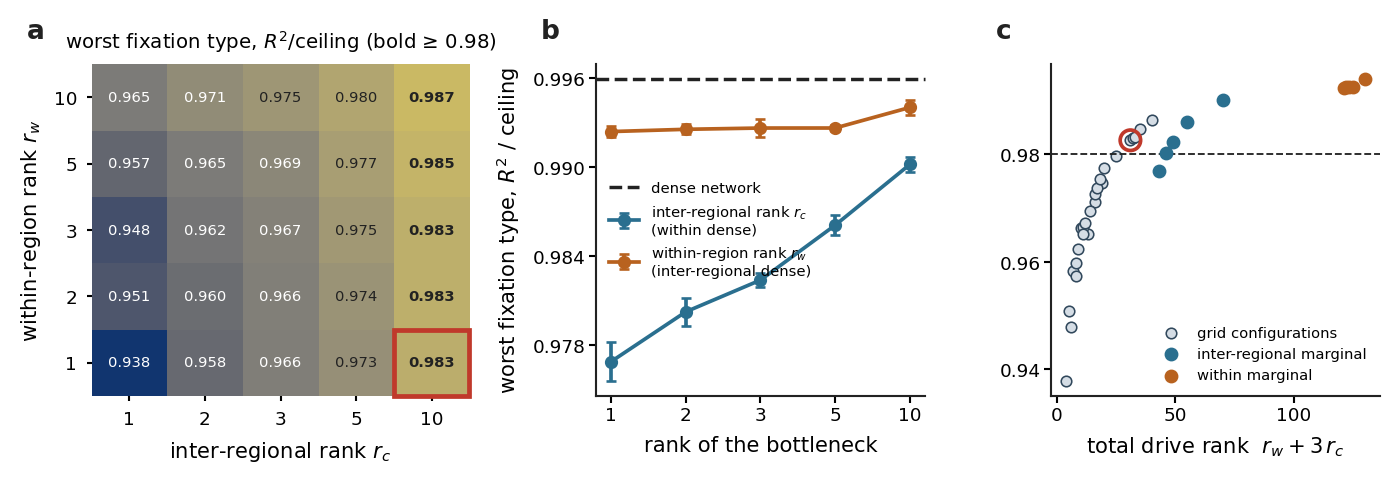

**Figure 5. How narrow each kind of connection can be.** (a) Worst fixation type (regions pooled per fit, minimum over fixation types, mean over five fits) of every $(r_w, r_c)$ configuration; bold is at or above 0.98; the red outline is the selected model. (b) The two marginals on one axis against the rank of the bottleneck: inter-regional rank with within-region recurrence dense (blue), and within-region rank with the pathways dense (orange); error bars are the sd over five fits, the dashed line the dense network. (c) Every configuration against the total drive rank $r_w + 3\,r_c$, with the selection bar dashed; the marginals do not collapse onto the grid, so the two constraints are not interchangeable by counting.

**Worst fixation type along each marginal** (dense network: 0.9959):

,inter-regional rank (within dense),within-region rank (inter-regional dense)
rank,,
1,0.9769,0.9924
2,0.9802,0.9925
3,0.9824,0.9926
5,0.9861,0.9926
10,0.9902,0.9940


**Selected model:** `w1_c10` — within-region rank 1, inter-regional rank 10, drive rank 31 of a possible 160 per area, worst fixation type 0.9826. Rule: *lowest drive rank with worst cell >= 0.98 of ceiling; ties to lower cross rank*.

In [6]:
figure(cviz.plot_rank_grid_composite(T["grid_fit"], T["dense_fit"], ranks=RANKS, hidden_units=HIDDEN_UNITS, bar=ADEQUATE_BAR, selected=SELECTED["label"]),
       "fig05_rank_grid",
       "**Figure 5. How narrow each kind of connection can be.** (a) Worst fixation type (regions pooled per fit, minimum over "
       "fixation types, mean over five fits) of every $(r_w, r_c)$ configuration; bold is at or above 0.98; the red outline is the "
       "selected model. (b) The two marginals on one axis against the rank of the bottleneck: inter-regional rank with within-region "
       "recurrence dense (blue), and within-region rank with the pathways dense (orange); error bars are the sd over five fits, the "
       "dashed line the dense network. (c) Every configuration against the total drive rank $r_w + 3\\,r_c$, with the selection bar "
       "dashed; the marginals do not collapse onto the grid, so the two constraints are not interchangeable by counting.")
per = T["grid_fit"].groupby(["label", "rank_within", "rank_cross", "seed", "condition"])["r2_vs_ceiling"].mean().reset_index()
worst_config = per.groupby(["label", "rank_within", "rank_cross", "seed"])["r2_vs_ceiling"].min().groupby(["rank_within", "rank_cross"]).mean()
dense_worst = T["dense_fit"].groupby(["seed", "condition"])["r2_vs_ceiling"].mean().groupby("seed").min().mean()
marg = pd.DataFrame({
    "inter-regional rank (within dense)": worst_config.xs(HIDDEN_UNITS, level="rank_within"),
    "within-region rank (inter-regional dense)": worst_config.xs(HIDDEN_UNITS, level="rank_cross"),
})
marg.index.name = "rank"
md(f"**Worst fixation type along each marginal** (dense network: {dense_worst:.4f}):")
display(marg.round(4))
md(f"**Selected model:** `{SELECTED['label']}` — within-region rank {SELECTED['within_region_bottleneck_dim']}, inter-regional rank "
   f"{SELECTED['recurrent_bottleneck_dim']}, drive rank {SELECTED['drive_rank']} of a possible {4 * HIDDEN_UNITS} per area, worst fixation "
   f"type {SELECTED['worst_condition']:.4f}. Rule: *{SELECTED['selection_rule']}*.")

The within-region marginal is flat: rank 1 on every area's own block gives a worst fixation
type of 0.992, against 0.996 for the dense network, and ranks 2, 3, 5 and 10 are no
better. An area's own recurrence can be a single direction. The inter-regional marginal is
steep: rank 1 on every pathway gives 0.977; rank 2, 0.980; rank 10, 0.990. The two curves
never approach each other at any rank, and panel (c) shows why the comparison is not just
counting: at equal total drive rank the configurations that spend their rank on the
pathways sit far above the ones that spend it within areas. Reading the grid interior, the
two constraints act almost independently — every row has the same profile across
inter-regional rank, shifted down by the small within-region cost — so the cheapest adequate
configuration is the one that squeezes within-region recurrence all the way and gives the
pathways what they need. That is the selected model: **every area's own block rank 1, every
pathway rank 10**, a total drive rank of 31 out of a possible 160 per area, with a worst
fixation type of 0.983.

### 3.5 Every bottleneck costs interactive face most

Figure 3 showed that interactive face gains most from the network. Figure 6 asks the
converse along each marginal: when a route is narrowed, does one fixation type pay more?
The cost is against the dense network for the same fixation type, regions pooled per fit,
and the brackets test whether the constraint widened the gap between interactive face and
each other fixation type (§2.13).

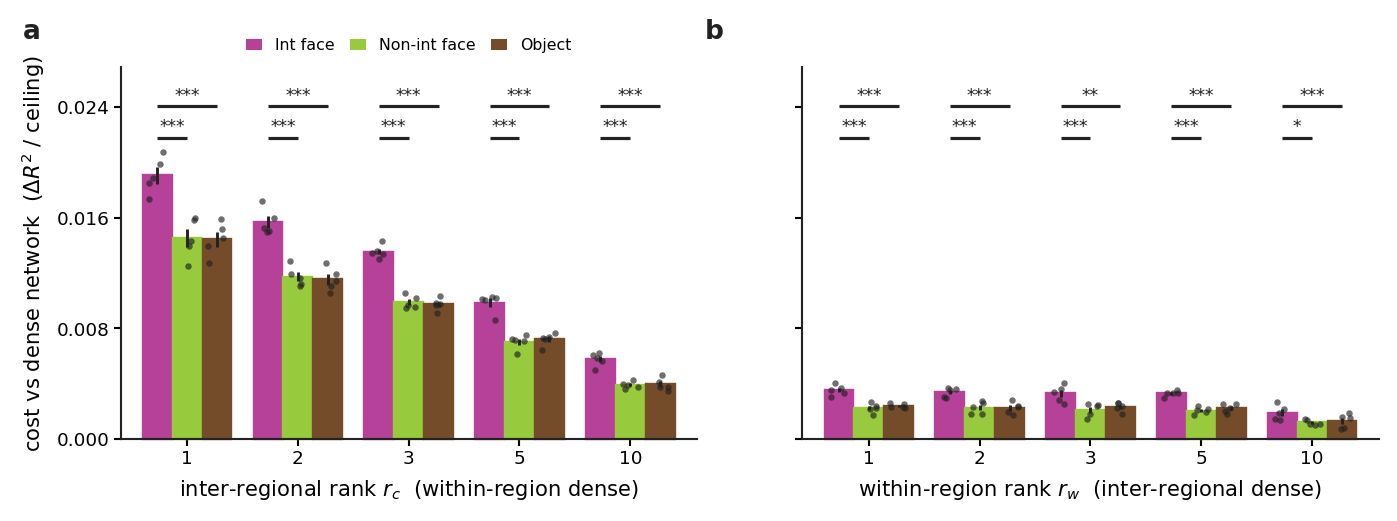

**Figure 6. Every bottleneck costs interactive face most, and the inter-regional bottleneck widens the gap.** Cost against the ten dense fits per fixation type, regions pooled per fit (five fits per configuration; bars: mean and SEM; dots: fits), along (a) the inter-regional marginal and (b) the within-region marginal, on one scale. Marks: the constraint widens the gap between interactive face and the marked fixation type (Welch's t on per-fit gaps against the dense fits, Holm-corrected within each panel).

**Cost of the inter-regional bottleneck** (within dense), per fixation type, mean over five fits:

condition,Int face,Non-int face,Object,Int face − others
rank,,,,
1,0.0190,0.0145,0.0144,0.0046
2,0.0157,0.0117,0.0115,0.0041
3,0.0135,0.0099,0.0097,0.0037
5,0.0098,0.0070,0.0072,0.0027
10,0.0057,0.0039,0.0040,0.0018


**Cost of the within-region bottleneck** (inter-regional dense):

condition,Int face,Non-int face,Object,Int face − others
rank,,,,
1,0.0035,0.0022,0.0024,0.0012
2,0.0034,0.0023,0.0022,0.0011
3,0.0033,0.0021,0.0023,0.0011
5,0.0033,0.0021,0.0022,0.0011
10,0.0019,0.0012,0.0013,0.0007


**Tests behind the brackets:**

,arm,a,b,difference,statistic,p,p_holm,stars
0,inter-regional rank 1,Int face,Non-int face,0.00453,22.51957,0.00000,0.00000,***
1,inter-regional rank 1,Int face,Object,0.00460,25.15896,0.00000,0.00000,***
2,inter-regional rank 2,Int face,Non-int face,0.00395,27.06510,0.00000,0.00000,***
3,inter-regional rank 2,Int face,Object,0.00416,23.63502,0.00000,0.00000,***
4,inter-regional rank 3,Int face,Non-int face,0.00366,22.40066,0.00000,0.00000,***
5,inter-regional rank 3,Int face,Object,0.00380,31.10550,0.00000,0.00000,***
6,inter-regional rank 5,Int face,Non-int face,0.00283,21.02362,0.00000,0.00000,***
7,inter-regional rank 5,Int face,Object,0.00265,17.49369,0.00000,0.00000,***
8,inter-regional rank 10,Int face,Non-int face,0.00184,9.82242,0.00005,0.00005,***
9,inter-regional rank 10,Int face,Object,0.00179,13.44747,0.00000,0.00000,***


In [7]:
gap6 = pd.concat([ch.gap_contrasts(MARGINAL_LONG[MARGINAL_LONG["side"].isin(["dense", side])], value="r2_vs_ceiling")
                  for side in ("inter-regional", "within-region")], ignore_index=True)
figure(cviz.plot_bottleneck_cost_by_condition(MARGINAL_COST, gap6, ranks=RANKS), "fig06_bottleneck_cost_by_condition",
       "**Figure 6. Every bottleneck costs interactive face most, and the inter-regional bottleneck widens the gap.** Cost against "
       "the ten dense fits per fixation type, regions pooled per fit (five fits per configuration; bars: mean and SEM; dots: fits), "
       "along (a) the inter-regional marginal and (b) the within-region marginal, on one scale. Marks: the constraint widens the gap "
       "between interactive face and the marked fixation type (Welch's t on per-fit gaps against the dense fits, Holm-corrected "
       "within each panel).")
cross_cost = MARGINAL_COST[MARGINAL_COST["side"] == "inter-regional"].groupby(["rank", "condition"])["cost"].mean().unstack("condition").rename(columns=COND)
within_cost = MARGINAL_COST[MARGINAL_COST["side"] == "within-region"].groupby(["rank", "condition"])["cost"].mean().unstack("condition").rename(columns=COND)
for frame in (cross_cost, within_cost):
    frame["Int face − others"] = frame["Int face"] - frame[["Non-int face", "Object"]].mean(axis=1)
md("**Cost of the inter-regional bottleneck** (within dense), per fixation type, mean over five fits:")
display(cross_cost.round(4))
md("**Cost of the within-region bottleneck** (inter-regional dense):")
display(within_cost.round(4))
md("**Tests behind the brackets:**")
show_tests(gap6, ["arm", "a", "b", "difference", "statistic", "p", "p_holm", "stars"])

At rank 1 on the pathways the cost is 0.019 for interactive face against 0.0145 for the
other two; at rank 10 it is 0.0057 against 0.0040. The extra cost to interactive face
shrinks with rank in absolute terms but stays about a third of the others' cost throughout,
and the widening of the gap is significant at every rank of both marginals. The
within-region bottleneck costs every fixation type little, and interactive face slightly
more than little (0.0035 against 0.0023). Interactive face is also the worst-fitted fixation
type in the dense network already and remains so in every configuration of the grid
(task 02b, §3); the bottleneck does not change which fixation type is hardest, it widens
the gap. Since these are five fits per configuration, the differential claim is made
properly on the ensemble next.

### 3.6 The selected network, refitted ten times: the cost of every constraint to every fixation type

The selected model (within-region rank 1, inter-regional rank 10) was refitted ten times and
read against the ten dense fits. Figure 7a gives the direct test of whether the constraint
costs one fixation type more; Figure 7b places every constraint of the chapter on the same
axis.

Constrained fits: worst fixation type 0.9829 (range 0.9818–0.9844), worst region × fixation-type combination 0.9789. Dense fits: worst fixation type 0.9959, worst combination 0.9913.

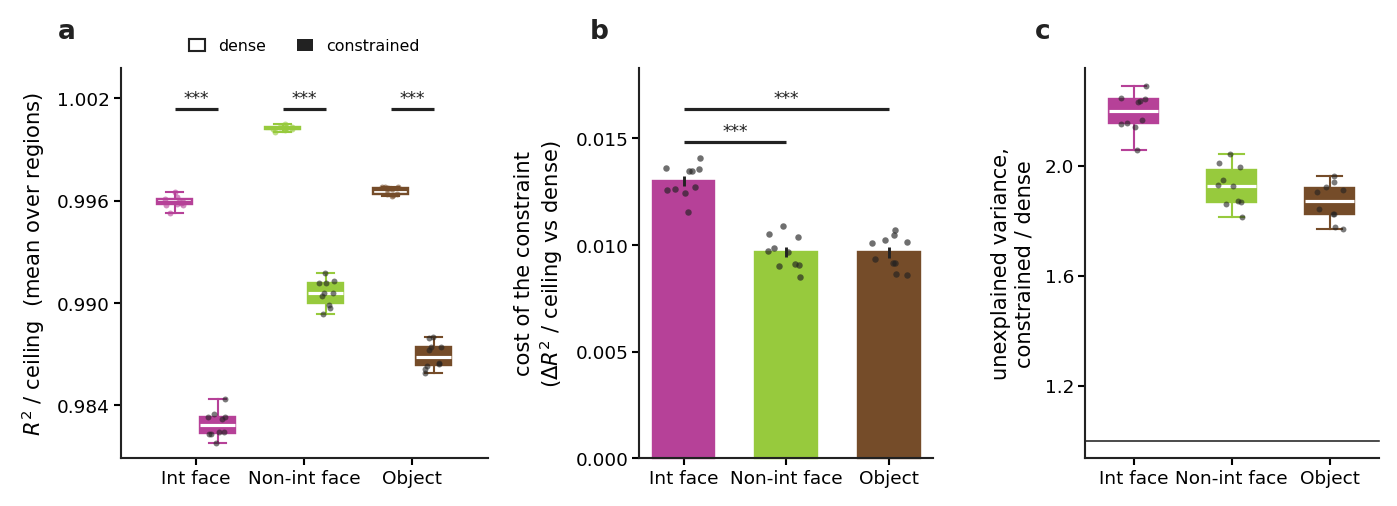

**Figure 7a. The selected constraint costs interactive face a third more than either other fixation type.** (a) Ceiling-relative $R^2$ per fixation type, regions pooled per fit, for the ten dense (white) and ten constrained (filled) fits, boxes with every fit a dot; marks: Welch's t between arms, Holm-corrected. (b) The cost of the constraint per fixation type, one value per constrained fit (bars: mean and SEM; dots: fits); marks: the constraint widens the gap between interactive face and the marked fixation type (Welch's t on per-fit gaps against the dense fits, Holm-corrected). (c) The scale-free reading: unexplained variance of each constrained fit over the dense mean.

**Cost per fixation type** (ten constrained fits against the dense mean) and the bootstrap intervals task 03 computed:

,dense_mean,constrained_mean,cost,cost_ci_low,cost_ci_high,unexplained_ratio,fi_extra_cost,fi_extra_cost_ci_low,fi_extra_cost_ci_high
condition,,,,,,,,,
Int face,0.9959,0.9829,0.0130,0.0125,0.0135,2.1925,NaN,NaN,NaN
Non-int face,1.0003,0.9906,0.0097,0.0092,0.0101,1.9274,0.0033,0.0027,0.004
Object,0.9966,0.9869,0.0097,0.0092,0.0101,1.8678,0.0034,0.0027,0.004


**Tests behind Figure 7a:**

,condition,a,b,n_a,n_b,difference,statistic,p,p_holm,stars
0,face_interactive,dense,"selected: within 1, inter-regional 10",10,10,0.01301,49.69622,0.0,0.0,***
1,face_non_interactive,dense,"selected: within 1, inter-regional 10",10,10,0.00967,39.32755,0.0,0.0,***
2,object,dense,"selected: within 1, inter-regional 10",10,10,0.00965,38.45862,0.0,0.0,***


,arm,a,b,n_arm,n_reference,difference,statistic,p,p_holm,stars
0,"selected: within 1, inter-regional 10",Int face,Non-int face,10,10,0.00334,24.85314,0.0,0.0,***
1,"selected: within 1, inter-regional 10",Int face,Object,10,10,0.00336,30.10952,0.0,0.0,***


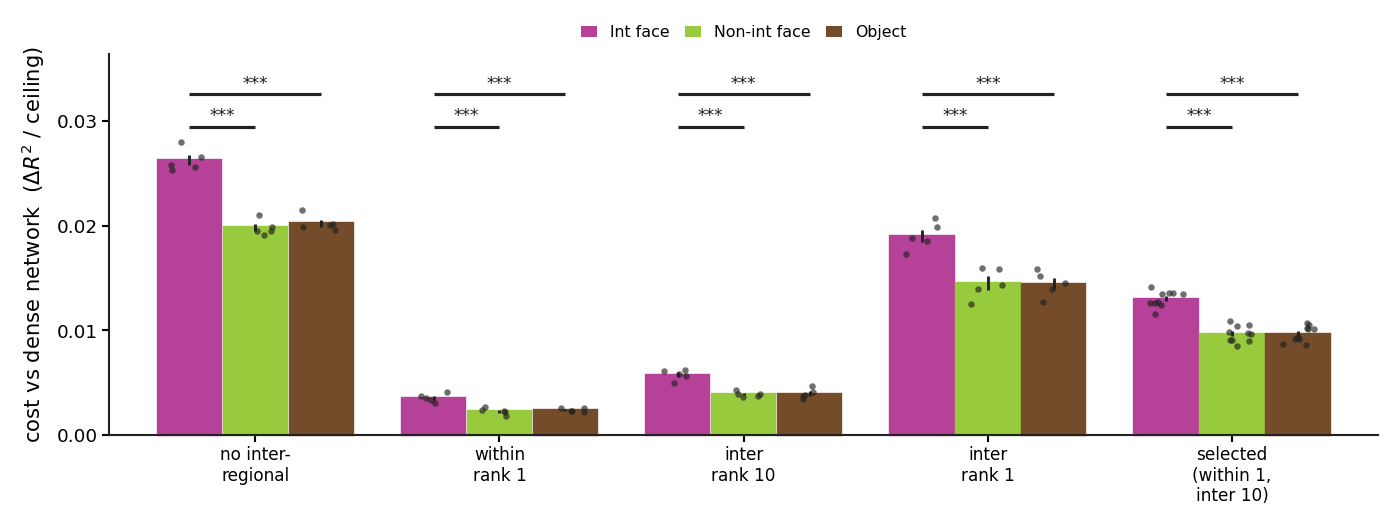

**Figure 7b. Every constraint in the chapter, costed on one footing.** Cost against the ten dense fits per fixation type for: every inter-regional connection removed (5 fits); within-region recurrence rank 1 (5); inter-regional pathways rank 10 (5); inter-regional pathways rank 1 (5); and the selected model, within 1 and inter-regional 10 (10 fits). Bars: mean and SEM; dots: fits. Marks: the constraint widens the gap between interactive face and the marked fixation type (Welch's t on per-fit gaps against the dense fits, Holm-corrected within the panel).

**Cost per constraint and fixation type** (mean over fits), and the ratio of interactive face's cost to the others':

condition,Int face,Non-int face,Object,Int face / mean of others
arm,,,,
no inter-regional connections,0.0262,0.0198,0.0202,1.3107
within-region rank 1,0.0035,0.0022,0.0024,1.5247
inter-regional rank 10,0.0057,0.0039,0.0040,1.4636
inter-regional rank 1,0.0190,0.0145,0.0144,1.3155
"selected: within 1, inter-regional 10",0.0130,0.0097,0.0097,1.3465


**Tests behind Figure 7b:**

,arm,a,b,n_arm,difference,statistic,p,p_holm,stars
0,no inter-regional connections,Int face,Non-int face,5,0.00642,34.58234,0.00000,0.00000,***
1,no inter-regional connections,Int face,Object,5,0.00602,26.49697,0.00000,0.00000,***
2,within-region rank 1,Int face,Non-int face,5,0.00128,11.92513,0.00000,0.00000,***
3,within-region rank 1,Int face,Object,5,0.00115,8.19582,0.00002,0.00005,***
4,inter-regional rank 10,Int face,Non-int face,5,0.00184,9.82242,0.00005,0.00005,***
5,inter-regional rank 10,Int face,Object,5,0.00179,13.44747,0.00000,0.00000,***
6,inter-regional rank 1,Int face,Non-int face,5,0.00453,22.51957,0.00000,0.00000,***
7,inter-regional rank 1,Int face,Object,5,0.00460,25.15896,0.00000,0.00000,***
8,"selected: within 1, inter-regional 10",Int face,Non-int face,10,0.00334,24.85314,0.00000,0.00000,***
9,"selected: within 1, inter-regional 10",Int face,Object,10,0.00336,30.10952,0.00000,0.00000,***


In [8]:
ens_fit = pd.concat([T["dense_fit"].assign(arm="dense"), T["ensemble_fit"].assign(arm="constrained")], ignore_index=True)
worst_cond = ens_fit.groupby(["arm", "seed", "condition"])["r2_vs_ceiling"].mean().groupby(["arm", "seed"]).min()
worst_combination = ens_fit.groupby(["arm", "seed", "region", "condition"])["r2_vs_ceiling"].mean().groupby(["arm", "seed"]).min()
md(f"Constrained fits: worst fixation type {worst_cond.loc['constrained'].mean():.4f} (range {worst_cond.loc['constrained'].min():.4f}–"
   f"{worst_cond.loc['constrained'].max():.4f}), worst region × fixation-type combination {worst_combination.loc['constrained'].mean():.4f}. "
   f"Dense fits: worst fixation type {worst_cond.loc['dense'].mean():.4f}, worst combination {worst_combination.loc['dense'].mean():.4f}.")
pair_arms = FIT_LONG[FIT_LONG["arm"].isin(["dense", SELECTED_ARM])]
arm_tests = ch.welch_contrasts(pair_arms, value="r2_vs_ceiling", group="arm", by="condition")
gap7a = ch.gap_contrasts(pair_arms, value="r2_vs_ceiling")
figure(cviz.plot_ensemble_cost(FIT_LONG, COST, arm_tests, gap7a, constrained=SELECTED_ARM), "fig07a_ensemble_cost",
       "**Figure 7a. The selected constraint costs interactive face a third more than either other fixation type.** (a) Ceiling-relative "
       "$R^2$ per fixation type, regions pooled per fit, for the ten dense (white) and ten constrained (filled) fits, boxes with every "
       "fit a dot; marks: Welch's t between arms, Holm-corrected. (b) The cost of the constraint per fixation type, one value per "
       "constrained fit (bars: mean and SEM; dots: fits); marks: the constraint widens the gap between interactive face and the "
       "marked fixation type (Welch's t on per-fit gaps against the dense fits, Holm-corrected). (c) The scale-free reading: "
       "unexplained variance of each constrained fit over the dense mean.")
md("**Cost per fixation type** (ten constrained fits against the dense mean) and the bootstrap intervals task 03 computed:")
display(T["fit_cost_by_condition"].assign(condition=T["fit_cost_by_condition"]["condition"].map(COND)).set_index("condition")
        [["dense_mean", "constrained_mean", "cost", "cost_ci_low", "cost_ci_high", "unexplained_ratio", "fi_extra_cost", "fi_extra_cost_ci_low", "fi_extra_cost_ci_high"]].round(4))
md("**Tests behind Figure 7a:**")
show_tests(arm_tests, ["condition", "a", "b", "n_a", "n_b", "difference", "statistic", "p", "p_holm", "stars"])
show_tests(gap7a, ["arm", "a", "b", "n_arm", "n_reference", "difference", "statistic", "p", "p_holm", "stars"])
gap7b = ch.gap_contrasts(FIT_LONG, value="r2_vs_ceiling")
figure(cviz.plot_constraint_cost_summary(COST, gap7b, constraints=ch.CONSTRAINT_ORDER), "fig07b_constraint_summary",
       "**Figure 7b. Every constraint in the chapter, costed on one footing.** Cost against the ten dense fits per fixation type "
       "for: every inter-regional connection removed (5 fits); within-region recurrence rank 1 (5); inter-regional pathways rank 10 "
       "(5); inter-regional pathways rank 1 (5); and the selected model, within 1 and inter-regional 10 (10 fits). Bars: mean and "
       "SEM; dots: fits. Marks: the constraint widens the gap between interactive face and the marked fixation type (Welch's t on "
       "per-fit gaps against the dense fits, Holm-corrected within the panel).")
summary = COST.groupby(["arm", "condition"])["cost"].mean().unstack("condition").rename(columns=COND).loc[list(ch.CONSTRAINT_ORDER)]
summary["Int face / mean of others"] = summary["Int face"] / summary[["Non-int face", "Object"]].mean(axis=1)
md("**Cost per constraint and fixation type** (mean over fits), and the ratio of interactive face's cost to the others':")
display(summary.round(4))
md("**Tests behind Figure 7b:**")
show_tests(gap7b, ["arm", "a", "b", "n_arm", "difference", "statistic", "p", "p_holm", "stars"])

The ten constrained fits reproduce the grid's five: worst fixation type 0.983 in every fit,
worst region × fixation-type combination 0.979 — the selected model sits at the selection
bar, not above it, and every fit is within 0.002 of every other. Against the ten dense fits
the constraint costs interactive face 0.0130 of ceiling-relative $R^2$ and the other two
fixation types 0.0097 each. The extra cost to interactive face, 0.0033 (bootstrap 95%
interval 0.0027–0.0040), is significant against both other fixation types (Welch's $t$ on
the per-fit gaps, $p < 0.001$), and the scale-free reading agrees: the constraint multiplies
interactive face's unexplained variance by 2.19, the others' by 1.93 and 1.87.

Figure 7b is the chapter's summary of what the constraints cost. Two things are on it. The
*size* of the costs orders the constraints: removing the pathways (0.020–0.026) and
squeezing them to rank 1 (0.014–0.019) are the expensive ones; the selected model
(0.010–0.013) pays for its rank-10 pathways plus its rank-1 recurrence; rank 10 alone
(0.004–0.006) and within-region rank 1 alone (0.002–0.004) are cheap. And the *ratio* is
the same for all of them: interactive face pays 1.3–1.5 times what the other two pay,
whichever route is constrained, and the widening is significant for every constraint.
Interactive face is the fixation type the inter-regional traffic is *for* — in the sense
that it loses most when that traffic is removed, narrowed, or, in the selected model, both
narrowed and made to carry an area's recurrence as well.

### 3.7 No particular pair of regions carries the fit

If the pathways carry the fit, is it a particular pathway? Figure 8 silences every pair of
areas in both directions in each of the twenty fits, along with every single pathway,
every within-region block, and every set of pathways into and out of one area.

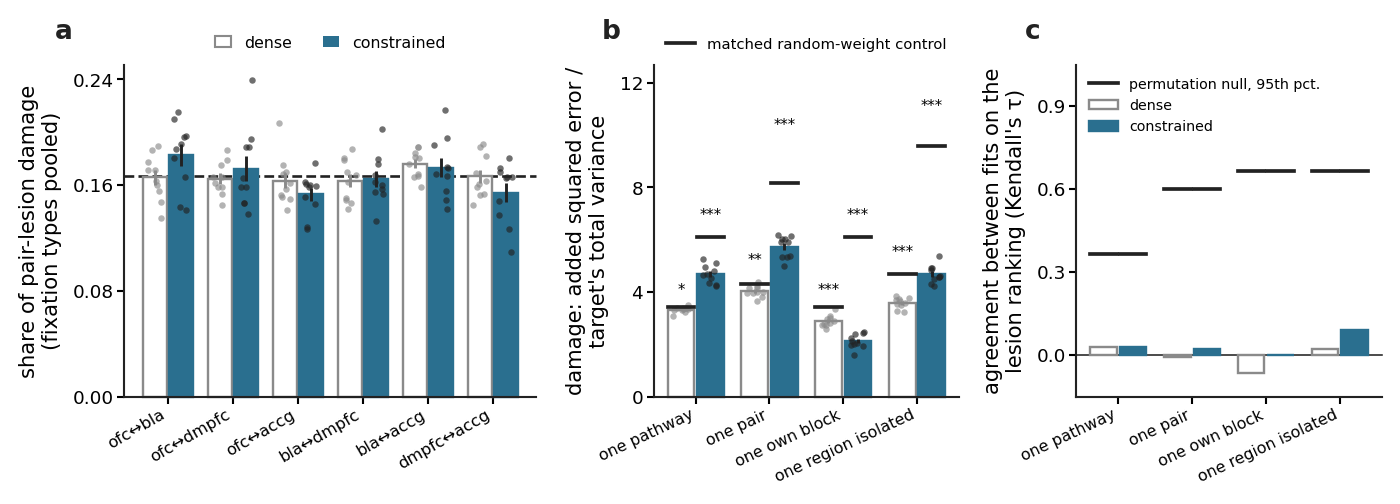

**Figure 8. Lesions are catastrophic and no pair is privileged.** (a) Each pair's share of the summed pair-lesion damage, fixation types pooled, ten fits per arm (dense white, constrained filled; bars: mean and SEM; dots: fits); the dashed line is one sixth. No pair's share differs from one sixth (one-sample t, Holm-corrected; nothing marked). (b) Damage per lesion family, mean over that family's lesions per fit, in units of the target's total variance, beside the matched control that silences the same number of randomly chosen weights (black line); stars: the family's damage differs from its control (paired t by fit, Holm-corrected). (c) Kendall's τ between fits' lesion rankings, per family and arm, against the 95th percentile of the permutation null (black line).

**Share of pair-lesion damage per pair** (mean ± sd over ten fits; chance is 0.167) and the one-sample tests:

mean                std       
arm        constrained  dense constrained  dense
pair                                            
bla↔accg         0.173  0.176       0.023  0.010
bla↔dmpfc        0.164  0.163       0.019  0.016
dmpfc↔accg       0.154  0.167       0.023  0.016
ofc↔accg         0.153  0.163       0.016  0.019
ofc↔bla          0.183  0.166       0.025  0.017
ofc↔dmpfc        0.172  0.165       0.031  0.012

,arm,pair,n,mean,statistic,p,p_holm,stars
0,constrained,bla↔accg,10,0.17305,0.88622,0.39856,1.00000,
1,constrained,bla↔dmpfc,10,0.16449,-0.37088,0.71930,1.00000,
2,constrained,dmpfc↔accg,10,0.15424,-1.70759,0.12189,1.00000,
3,constrained,ofc↔accg,10,0.15299,-2.78354,0.02128,0.23455,
4,constrained,ofc↔bla,10,0.18279,2.00196,0.07631,0.76311,
5,constrained,ofc↔dmpfc,10,0.17244,0.59320,0.56766,1.00000,
6,dense,bla↔accg,10,0.17608,2.83552,0.01955,0.23455,
7,dense,bla↔dmpfc,10,0.16329,-0.67302,0.51784,1.00000,
8,dense,dmpfc↔accg,10,0.16652,-0.02853,0.97786,1.00000,
9,dense,ofc↔accg,10,0.16338,-0.56027,0.58897,1.00000,


**Damage per lesion family** (per-fit mean, summed over the twelve combinations — a drop in pooled $R^2$) against the matched control:

...

,arm,family,n,difference,statistic,p,p_holm,stars
0,constrained,bidirectional,10,-2.43790,-10.06118,0.00000,0.00001,***
1,constrained,directed,10,-1.41263,-11.19776,0.00000,0.00001,***
2,constrained,isolation,10,-4.89579,-30.21231,0.00000,0.00000,***
3,constrained,within-region,10,-3.97533,-26.94349,0.00000,0.00000,***
4,dense,bidirectional,10,-0.28026,-3.73720,0.00465,0.00929,**
5,dense,directed,10,-0.11022,-3.07072,0.01334,0.01334,*
6,dense,isolation,10,-1.09118,-8.93562,0.00001,0.00003,***
7,dense,within-region,10,-0.54659,-12.28522,0.00000,0.00000,***


**Do the ten fits agree on which lesions hurt most?**

n_lesions  tau_mean  tau_min  null_p95  clears_null
arm         lesion_kind                                                       
constrained bidirectional          6     0.022   -0.733     0.600        False
            directed              12     0.029   -0.394     0.364        False
            isolation              4     0.089   -0.667     0.667        False
            within-region          4     0.000   -1.000     0.667        False
dense       bidirectional          6    -0.007   -0.600     0.600        False
            directed              12     0.029   -0.424     0.364        False
            isolation              4     0.022   -0.667     0.667        False
            within-region          4    -0.067   -1.000     0.667        False

**Per fixation type**, the pair that hurts most on average and the fraction of fits in which it is the top pair:

tau_mean  null_p95  top_lesion  top_lesion_is_top_in
arm         condition                                                         
constrained Int face        -0.064       0.6     ofc↔bla                   0.3
            Non-int face    -0.043       0.6     ofc↔bla                   0.1
            Object           0.040       0.6     ofc↔bla                   0.4
dense       Int face        -0.004       0.6    bla↔accg                   0.3
            Non-int face     0.067       0.6  dmpfc↔accg                   0.4
            Object           0.052       0.6    bla↔accg                   0.1

In [9]:
pair_share = ch.pair_lesion_share(T["lesion_battery"])
share_tests = ch.one_sample_contrasts(pair_share, value="share", by=["arm", "pair"], popmean=1 / 6)
damage = ch.lesion_damage_per_fit(T["lesion_battery"])
damage_long = pd.concat([damage.assign(kind="lesion", value=damage["damage"]), damage.assign(kind="control", value=damage["control"])])
damage_tests = ch.paired_contrasts(damage_long, value="value", group="kind", unit="seed", by=["arm", "family"], pairs=[("lesion", "control")])
figure(cviz.plot_pair_lesion_summary(pair_share, share_tests, damage, damage_tests, T["lesion_ranking_agreement"]), "fig08_pair_lesions",
       "**Figure 8. Lesions are catastrophic and no pair is privileged.** (a) Each pair's share of the summed pair-lesion damage, "
       "fixation types pooled, ten fits per arm (dense white, constrained filled; bars: mean and SEM; dots: fits); the dashed line "
       "is one sixth. No pair's share differs from one sixth (one-sample t, Holm-corrected; nothing marked). (b) Damage per lesion "
       "family, mean over that family's lesions per fit, in units of the target's total variance, beside the matched control that "
       "silences the same number of randomly chosen weights (black line); stars: the family's damage differs from its control "
       "(paired t by fit, Holm-corrected). (c) Kendall's τ between fits' lesion rankings, per family and arm, against the 95th "
       "percentile of the permutation null (black line).")
md("**Share of pair-lesion damage per pair** (mean ± sd over ten fits; chance is 0.167) and the one-sample tests:")
display(pair_share.groupby(["arm", "pair"])["share"].agg(["mean", "std"]).unstack("arm").round(3))
show_tests(share_tests, ["arm", "pair", "n", "mean", "statistic", "p", "p_holm", "stars"])
md("**Damage per lesion family** (per-fit mean, summed over the twelve combinations — a drop in pooled $R^2$) against the matched control:")
display(damage.groupby(["arm", "family"])[["damage", "control"]].agg(["mean", "std"]).round(2))
show_tests(damage_tests, ["arm", "family", "n", "difference", "statistic", "p", "p_holm", "stars"])
md("**Do the ten fits agree on which lesions hurt most?**")
display(T["lesion_ranking_agreement"].set_index(["arm", "lesion_kind"])[["n_lesions", "tau_mean", "tau_min", "null_p95", "clears_null"]].round(3))
top = T["lesion_ranking_by_condition"]
top = top[top["lesion_kind"] == "bidirectional"].assign(condition=top["condition"].map(COND))
md("**Per fixation type**, the pair that hurts most on average and the fraction of fits in which it is the top pair:")
display(top.set_index(["arm", "condition"])[["tau_mean", "null_p95", "top_lesion", "top_lesion_is_top_in"]].round(3))

Two things are true at once. **Every lesion is catastrophic**: silencing one pair of
pathways adds squared error equal to four times the target's total variance in the dense
network and nearly six times in the constrained one — the pooled $R^2$ falls from 0.99 to
about $-3$ — and a single pathway or a single within-region block does almost as much.
This is the signature of a finely tuned system, not of a load-bearing connection: the
matched random control, which silences the same number of weights chosen anywhere in the
network, does as much or more damage than every lesion family (every family differs from
its control, and in the direction of the control being worse). **And no pair is special**:
each of the six pairs accounts for 0.15–0.18 of the summed pair-lesion damage in both arms,
no pair's share differs from one sixth after correction, and the fit-to-fit spread is wider
than any difference between pairs. The ten fits do not agree on which pair matters most
(Kendall's $\tau$ between fits is $-0.07$ to 0.09 for every lesion family in both arms, all
far below the permutation null's 95th percentile), and they do not agree per fixation type
either: the pair that hurts interactive face most on average is the top pair in three of
ten fits in either arm.

So the answer to "which pathway carries the interactive-face trajectory" is that in these
data the question has no stable answer. What the fits agree on is the *amount* of traffic
and its *rank*; the routing is one of the things the solution set leaves free.

### 3.8 What a lesion does to the local dynamics

Damage to the fit says how much a lesion matters; it does not say what the lesion does to
the system. Figure 8b reads each pair lesion and each isolation as a change in the
network's local linearisation (§2.12): the eigenvalues of the Jacobian, for each region's
own block and for the whole network, at the fixed point nearest the end of the lesioned
trajectory and along the lesioned trajectory, with the change scored as the Wasserstein
distance between the lesioned and the intact spectrum. Two questions: does a lesion move
the local dynamics of one fixation type more than another, and does it move one region's
more than another's?

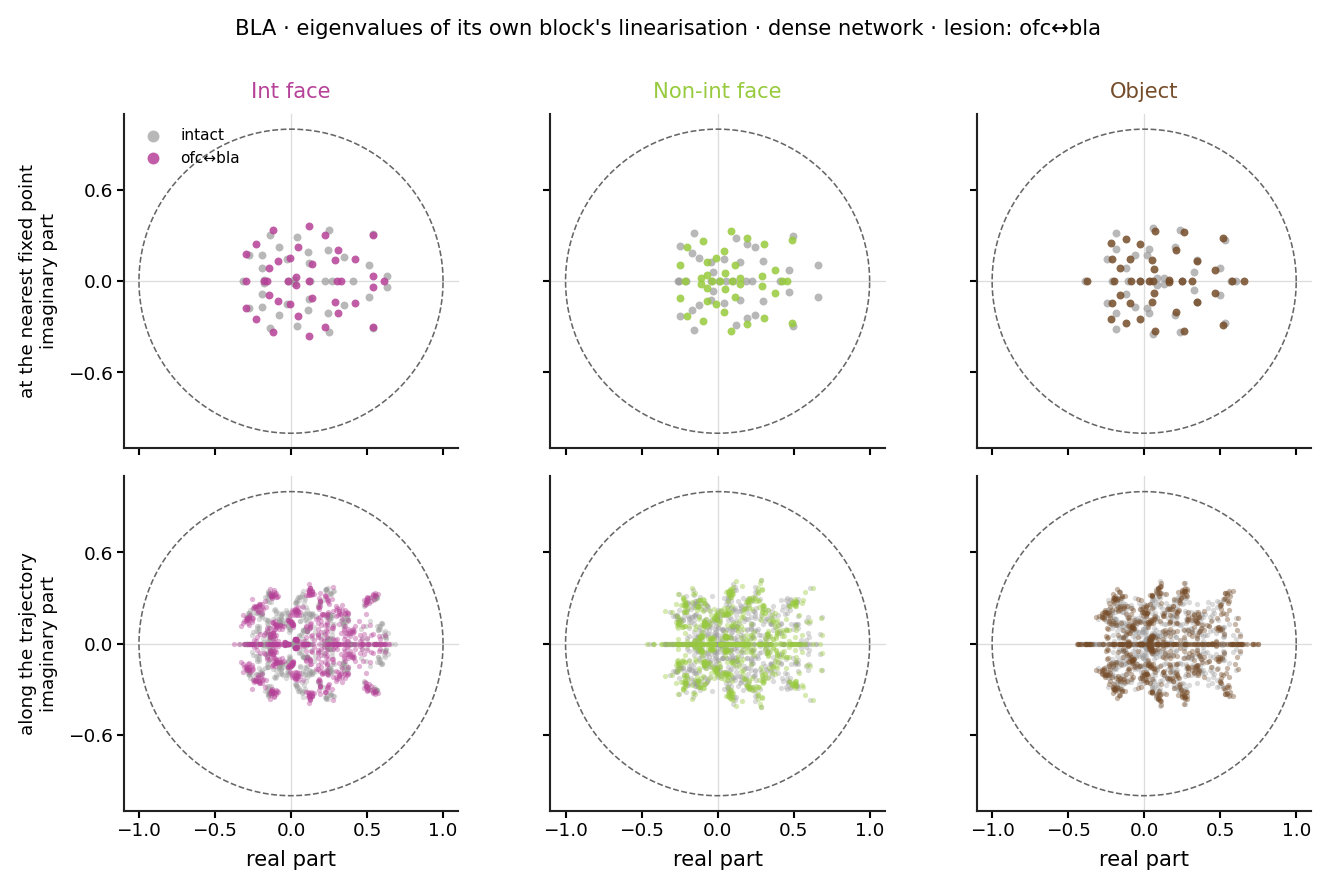

**Figure 8b. What a pair lesion does to a region's local dynamics: one dense fit (seed 1343419791), BLA's own block.** Eigenvalues of $\mathrm{diag}(1 - h_r^2)\,W_{rr}$ in the complex plane, intact (grey) and after silencing ofc↔bla in both directions (colour), per fixation type. Top: at the fixed point nearest the end of the trajectory. Bottom: along the trajectory, every fifth state pooled. The dashed circle is the unit circle.

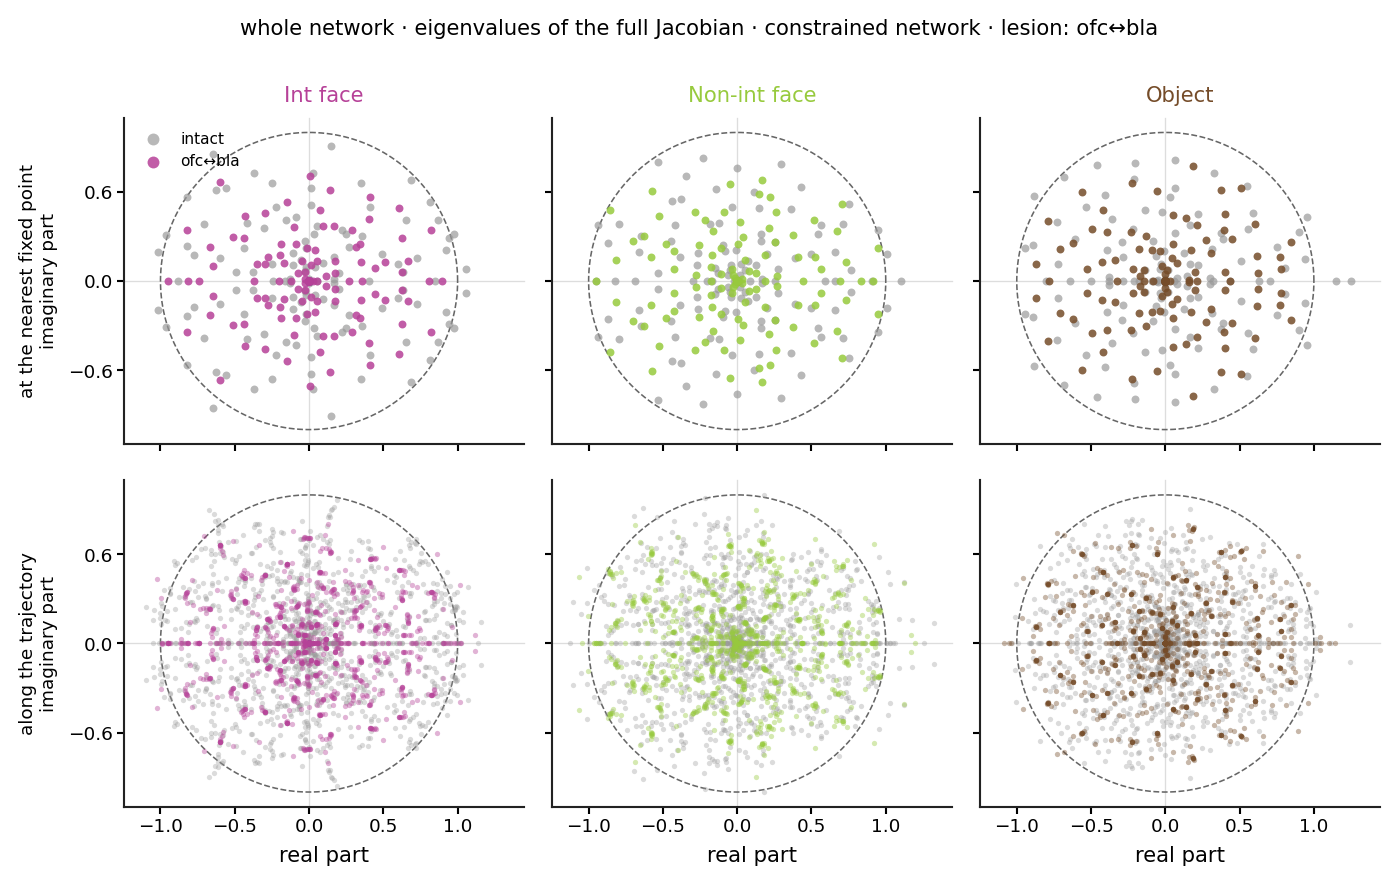

**Figure 8c. The same lesion in one constrained fit (seed 2044133302), whole-network linearisation.** Eigenvalues of $\mathrm{diag}(1 - h^2)\,W$ for all 160 units, intact (grey) and after silencing ofc↔bla (colour), per fixation type, at the fixed point (top) and along the trajectory (bottom). Under the selected constraint each region's own block is rank 1, so the whole-network spectrum is the informative one for this arm.

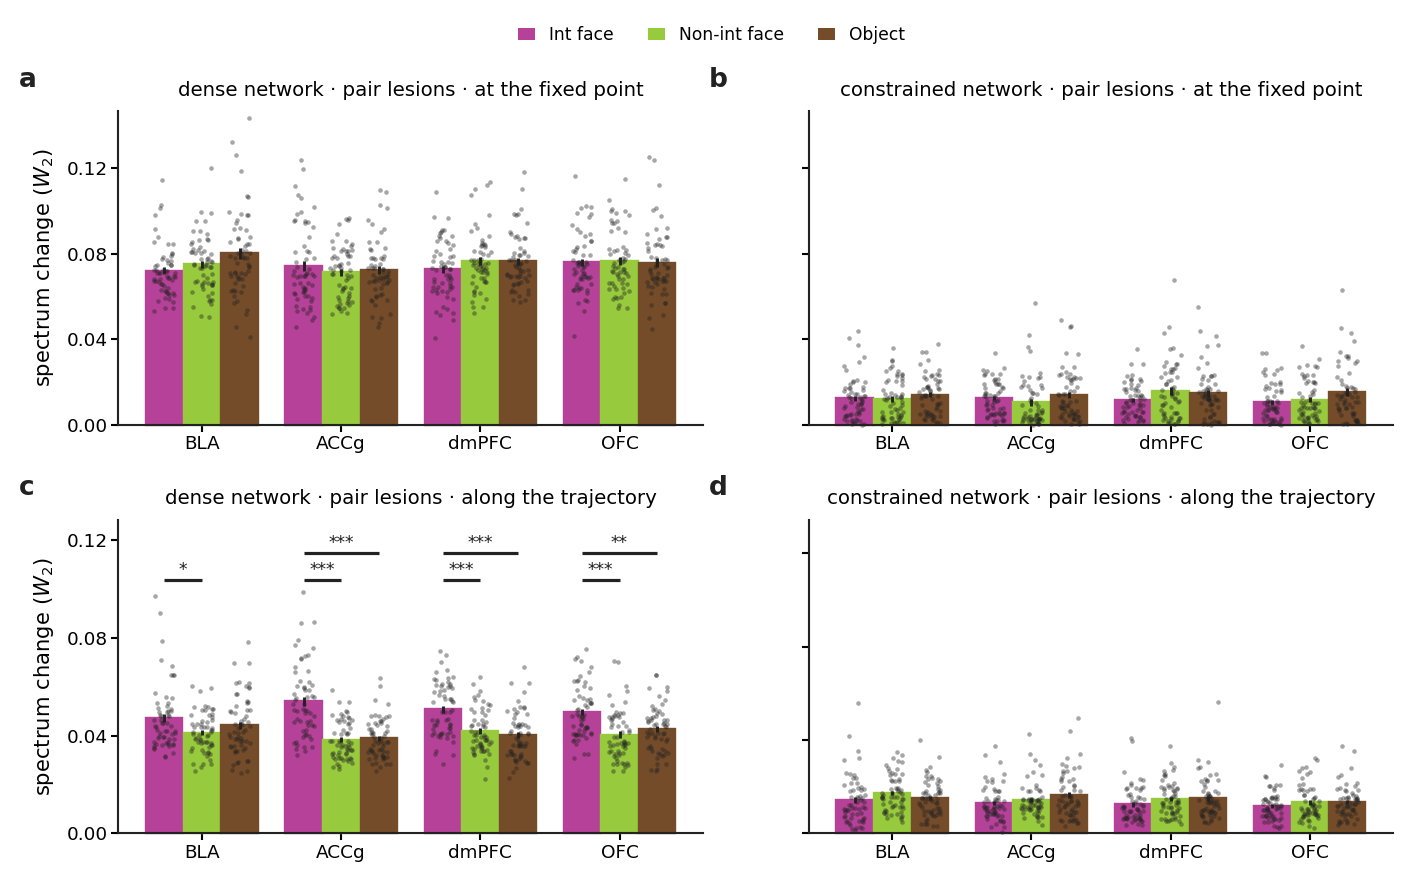

**Figure 8d. How far a pair lesion moves each region's local spectrum, per fixation type.** 2-Wasserstein distance between the lesioned and intact eigenvalues of a region's own block, every fit × pair lesion a value (60 per bar; bars: mean and SEM), at the fixed point (top row) and along the trajectory (bottom row), dense (left) and constrained (right). Marks: paired t between fixation types by fit × lesion, Holm-corrected within each panel; only significant contrasts are marked.

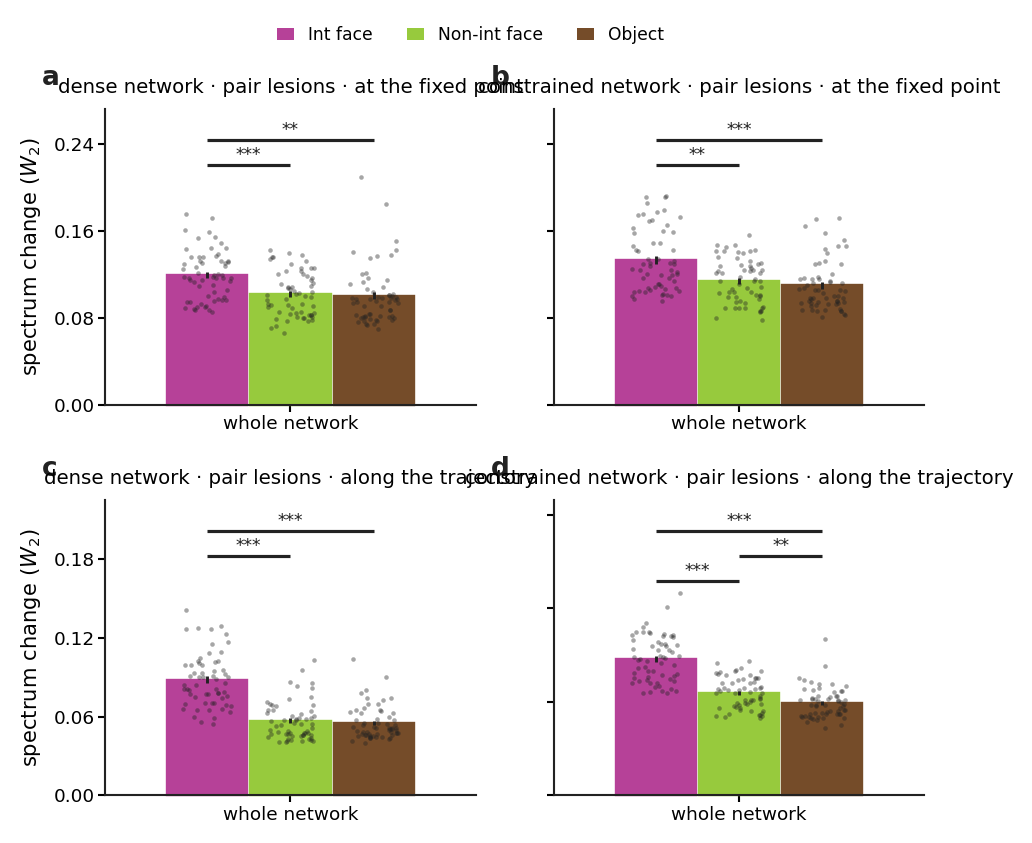

**Figure 8e. The same for the whole-network linearisation.** 2-Wasserstein distance between the lesioned and intact spectra of the full 160-unit Jacobian, every fit × pair lesion a value, at the fixed point (top) and along the trajectory (bottom); marks as in Figure 8d.

**Wasserstein distance to the intact spectrum** (mean over fits × pair lesions), per region, fixation type, arm and linearisation point:

condition                        Int face  Non-int face  Object
where       arm         region                                 
fixed_point constrained accg       0.0124        0.0104  0.0139
                        bla        0.0122        0.0120  0.0139
                        dmpfc      0.0116        0.0158  0.0146
                        network    0.1335        0.1142  0.1099
                        ofc        0.0105        0.0115  0.0153
            dense       accg       0.0744        0.0712  0.0725
                        bla        0.0721        0.0750  0.0802
                        dmpfc      0.0727        0.0766  0.0765
                        network    0.1197        0.1022  0.1004
                        ofc        0.0760        0.0767  0.0758
trajectory  constrained accg       0.0098        0.0109  0.0122
                        bla        0.0108        0.0130  0.0114
                        dmpfc      0.0094        0.0111  0.0113
                        network    0.1170        0.0877  0.0793
                        ofc        0.0088        0.0100  0.0102
            dense       accg       0.0541        0.0384  0.0389
                        bla        0.0474        0.0411  0.0443
                        dmpfc      0.0508        0.0418  0.0402
                        network    0.0879        0.0569  0.0552
                        ofc        0.0497        0.0404  0.0427

**Isolations**, for comparison:

condition                        Int face  Non-int face  Object
where       arm         region                                 
fixed_point constrained accg       0.0107        0.0135  0.0131
                        bla        0.0150        0.0109  0.0158
                        dmpfc      0.0145        0.0153  0.0184
                        network    0.2654        0.2333  0.2253
                        ofc        0.0121        0.0123  0.0118
            dense       accg       0.0679        0.0724  0.0816
                        bla        0.0768        0.0866  0.0912
                        dmpfc      0.0745        0.0826  0.0795
                        network    0.1607        0.1354  0.1295
                        ofc        0.0799        0.0807  0.0858
trajectory  constrained accg       0.0113        0.0147  0.0156
                        bla        0.0147        0.0148  0.0152
                        dmpfc      0.0129        0.0170  0.0167
                        network    0.2637        0.2267  0.2174
                        ofc        0.0117        0.0137  0.0137
            dense       accg       0.0577        0.0584  0.0642
                        bla        0.0656        0.0682  0.0721
                        dmpfc      0.0625        0.0675  0.0649
                        network    0.1421        0.1072  0.1030
                        ofc        0.0649        0.0660  0.0701

...

top_modulus  n_expanding
where       arm         region                           
fixed_point constrained accg           0.320        0.000
                        bla            0.223        0.000
                        dmpfc          0.263        0.000
                        network        1.056        3.600
                        ofc            0.255        0.000
            dense       accg           0.662        0.000
                        bla            0.635        0.000
                        dmpfc          0.639        0.000
                        network        1.058        6.533
                        ofc            0.652        0.000
trajectory  constrained accg           0.419        0.000
                        bla            0.341        0.000
                        dmpfc          0.398        0.000
                        network        1.270        4.553
                        ofc            0.339        0.000
            dense       accg           0.746        0.000
                        bla            0.741        0.000
                        dmpfc          0.718        0.000
                        network        1.193        5.397
                        ofc            0.742        0.000

Fixed-point searches on the lesioned maps converged in **98%** of cases; the remainder use the slowest point found.

**Tests behind Figures 8d and 8e:**

,arm,where,region,a,b,n,difference,statistic,p,p_holm,stars
12,dense,fixed_point,network,Int face,Non-int face,60,0.01756,4.87882,0.00001,0.00013,***
13,dense,fixed_point,network,Int face,Object,60,0.01932,4.10418,0.00013,0.00177,**
15,dense,trajectory,ofc,Int face,Non-int face,60,0.00928,4.80462,0.00001,0.00010,***
16,dense,trajectory,ofc,Int face,Object,60,0.00700,3.96046,0.00020,0.00163,**
18,dense,trajectory,bla,Int face,Non-int face,60,0.00621,3.29941,0.00165,0.01152,*
21,dense,trajectory,dmpfc,Int face,Non-int face,60,0.00901,5.17762,0.00000,0.00003,***
22,dense,trajectory,dmpfc,Int face,Object,60,0.01060,7.00417,0.00000,0.00000,***
24,dense,trajectory,accg,Int face,Non-int face,60,0.01563,7.47357,0.00000,0.00000,***
25,dense,trajectory,accg,Int face,Object,60,0.01516,8.06645,0.00000,0.00000,***
27,dense,trajectory,network,Int face,Non-int face,60,0.03104,11.50251,0.00000,0.00000,***


(16 of 60 contrasts significant after Holm correction.)

In [10]:
spectra_summary = cached("lesion_region_spectra", lambda: ch.collect_lesion_spectra(ARMS, kinds=("bidirectional", "isolation")))
spectra_summary["unit"] = spectra_summary["seed"].astype(str) + "|" + spectra_summary["lesion"]
lesioned = spectra_summary[spectra_summary["lesion_kind"] != "intact"]
# Representative fit per arm: the one whose worst combination sits at the median of its arm.
representative = {}
for arm in ARMS:
    ordered = worst_combination.loc[arm].sort_values()
    representative[arm] = str(ordered.index[len(ordered) // 2])
rep_path = TASK_ROOT / "tables" / "lesion_region_spectra_representative.csv"
rep_spectra = pd.read_csv(rep_path) if rep_path.exists() else pd.DataFrame()
if "seed" in rep_spectra.columns:
    rep_spectra["seed"] = rep_spectra["seed"].astype(str)
frames = []
for arm, seed in representative.items():
    block = rep_spectra[(rep_spectra["arm"] == arm) & (rep_spectra["seed"] == seed)] if not rep_spectra.empty else pd.DataFrame()
    if block.empty:
        run_dir = next(d for d in audit.seed_run_dirs(ARMS[arm]) if ens.seed_of(d) == seed)
        _, block = ch.lesion_region_spectra(run_dir, kinds=("bidirectional", "isolation"), keep_spectra=True)
        block = block.assign(arm=arm)
        block["seed"] = block["seed"].astype(str)
        rep_spectra = pd.concat([rep_spectra, block], ignore_index=True)
        rep_spectra.to_csv(rep_path, index=False)
    frames.append(block)
rep_spectra = pd.concat(frames, ignore_index=True)
CLOUD_LESION = "ofc↔bla"
figure(cviz.plot_lesion_spectra_clouds(rep_spectra[rep_spectra["arm"] == "dense"], region=TRACE_REGION, lesion=CLOUD_LESION, arm="dense"),
       "fig08b_spectra_clouds_dense_bla",
       f"**Figure 8b. What a pair lesion does to a region's local dynamics: one dense fit (seed {representative['dense']}), "
       f"{REGION_LABELS[TRACE_REGION]}'s own block.** Eigenvalues of $\\mathrm{{diag}}(1 - h_r^2)\\,W_{{rr}}$ in the complex plane, intact (grey) "
       f"and after silencing {CLOUD_LESION} in both directions (colour), per fixation type. Top: at the fixed point nearest the end of the "
       "trajectory. Bottom: along the trajectory, every fifth state pooled. The dashed circle is the unit circle.")
figure(cviz.plot_lesion_spectra_clouds(rep_spectra[rep_spectra["arm"] == "constrained"], region="network", lesion=CLOUD_LESION, arm="constrained"),
       "fig08c_spectra_clouds_constrained_network",
       f"**Figure 8c. The same lesion in one constrained fit (seed {representative['constrained']}), whole-network linearisation.** "
       f"Eigenvalues of $\\mathrm{{diag}}(1 - h^2)\\,W$ for all 160 units, intact (grey) and after silencing {CLOUD_LESION} (colour), per "
       "fixation type, at the fixed point (top) and along the trajectory (bottom). Under the selected constraint each region's own "
       "block is rank 1, so the whole-network spectrum is the informative one for this arm.")
w2_tests = pd.concat([
    ch.paired_contrasts(lesioned[(lesioned["arm"] == arm) & (lesioned["where"] == where) & (lesioned["lesion_kind"] == "bidirectional")],
                        value="w2_to_intact", unit="unit", by="region").assign(arm=arm, where=where)
    for arm in ARMS for where in ("fixed_point", "trajectory")], ignore_index=True)
figure(cviz.plot_lesion_spectra_distance(lesioned, w2_tests, lesion_kind="bidirectional"), "fig08d_spectra_distance_regions",
       "**Figure 8d. How far a pair lesion moves each region's local spectrum, per fixation type.** 2-Wasserstein distance between the "
       "lesioned and intact eigenvalues of a region's own block, every fit × pair lesion a value (60 per bar; bars: mean and SEM), at "
       "the fixed point (top row) and along the trajectory (bottom row), dense (left) and constrained (right). Marks: paired t "
       "between fixation types by fit × lesion, Holm-corrected within each panel; only significant contrasts are marked.")
figure(cviz.plot_lesion_spectra_distance(lesioned, w2_tests, lesion_kind="bidirectional", regions=("network",), figsize=(5.0, 4.4)),
       "fig08e_spectra_distance_network",
       "**Figure 8e. The same for the whole-network linearisation.** 2-Wasserstein distance between the lesioned and intact spectra of "
       "the full 160-unit Jacobian, every fit × pair lesion a value, at the fixed point (top) and along the trajectory (bottom); "
       "marks as in Figure 8d.")
md("**Wasserstein distance to the intact spectrum** (mean over fits × pair lesions), per region, fixation type, arm and linearisation point:")
display(lesioned[lesioned["lesion_kind"] == "bidirectional"].groupby(["where", "arm", "region", "condition"])["w2_to_intact"].mean()
        .unstack("condition").rename(columns=COND).round(4))
md("**Isolations**, for comparison:")
display(lesioned[lesioned["lesion_kind"] == "isolation"].groupby(["where", "arm", "region", "condition"])["w2_to_intact"].mean()
        .unstack("condition").rename(columns=COND).round(4))
md("**Largest eigenvalue modulus and expanding modes of the intact linearisation**, per region and arm (mean over fits and fixation types):")
display(spectra_summary[spectra_summary["lesion_kind"] == "intact"].groupby(["where", "arm", "region"])[["top_modulus", "n_expanding"]].mean().round(3))
md(f"Fixed-point searches on the lesioned maps converged in **{100 * spectra_summary['fixed_point_converged'].mean():.0f}%** of cases; "
   "the remainder use the slowest point found.")
md("**Tests behind Figures 8d and 8e:**")
show_tests(w2_tests[w2_tests["significant"]], ["arm", "where", "region", "a", "b", "n", "difference", "statistic", "p", "p_holm", "stars"])
md(f"({int(w2_tests['significant'].sum())} of {len(w2_tests)} contrasts significant after Holm correction.)")

**Reading.** The two scopes tell two stories. At the scope of a region's own block
(Figures 8b, 8d) a pair lesion moves the local spectrum little. In the dense network the
lesioned eigenvalues sit on top of the intact ones — a distance of 0.07–0.08 at the fixed
point and 0.04–0.05 along the trajectory, against eigenvalue moduli of 0.6–0.75 — and the
constrained network's blocks, being rank one, barely move at all (0.01–0.02). At this scope
the fixation type matters only along the trajectory of the dense network, where interactive
face's block spectra move most in every region (significantly more than both other
fixation types in ACCg, dmPFC and OFC, and than non-interactive face in BLA); at the fixed
point no fixation-type contrast is significant in either arm, and the change is the same
size in all four regions. No region is singled out anywhere.

At the scope of the whole network (Figures 8c, 8e) the lesion's effect is larger — 0.10–0.13
at the fixed point and 0.06–0.12 along the trajectory, on a spectrum whose leading modes sit
just outside the unit circle (largest modulus 1.06 at the fixed point, 1.2–1.3 along the
trajectory) — and it is unmistakably largest for interactive face. At the fixed point and
along the trajectory, in both arms, the interactive-face map's spectrum moves further than
either other fixation type's: along the trajectory 0.117 against 0.088 and 0.079 in the
constrained network and 0.088 against 0.057 and 0.055 in the dense one, every one of the
eight contrasts (two fixation-type pairs × two arms × two linearisation points) significant
after correction; along the constrained trajectory non-interactive face also moves more than
object. So the same lesion that leaves interactive face's
trajectory *extent* unchanged (Figure 11) changes its *local dynamics* most. Both are what a
state held in place by inter-regional traffic would show: remove the traffic and the local
flow around that state reorganises, while the trajectory, no longer being pushed out, does
not expand the way the other two do.

### 3.9 The dynamical picture: interactive face is the slow, compact state

The last question is what the fitted network does, as a dynamical system, for each fixation
type. Because the input is constant, each fixation type turns the network into an
autonomous map; the three maps differ in a fixed input vector and a trained initial state.
Figure 9 shows the flow of each map in the plane of the two leading state axes for one
representative fit per arm (the fit whose worst combination is the median of its arm), with
the trajectory the network runs from the first bin of the window to the last. Figure 10
compares the three fixation types on the three quantities that summarise that picture —
how large, how fast, and how locally expansive the trajectory is — across all twenty fits,
and Figure 11 what a lesion does to the trajectories.

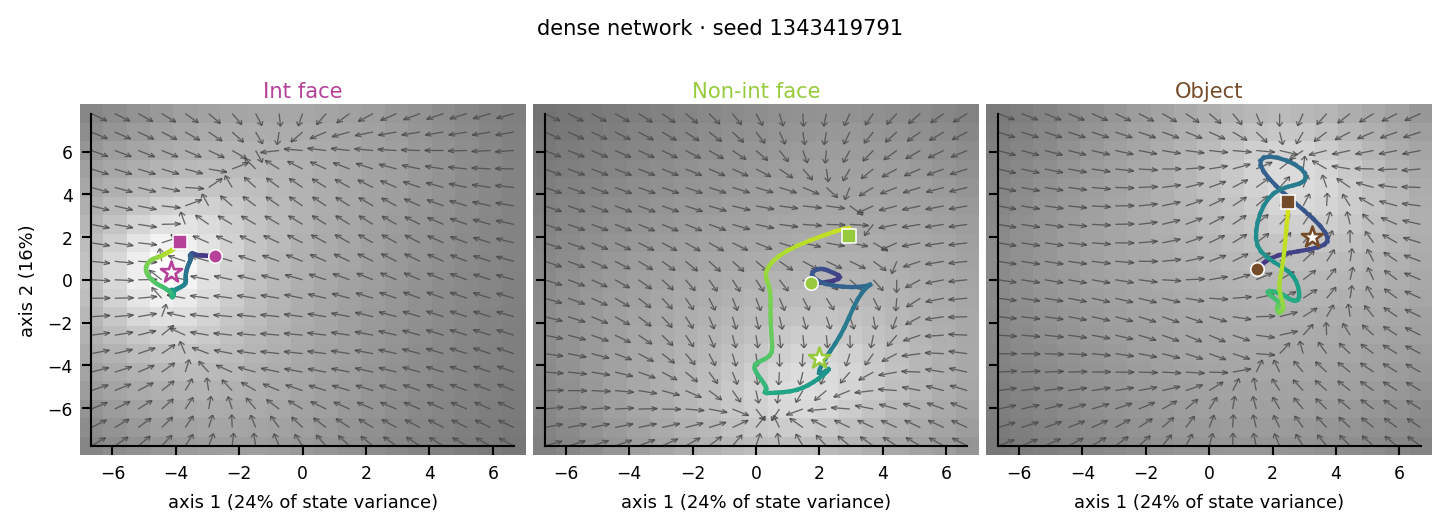

**Figure 9 (dense). The flow of each fixation type's map, one fit.** Each panel is the autonomous map for one fixation type in the plane of the two leading principal axes of the pooled hidden-state trajectories (the same plane in all three; the percentages are the share of hidden-state variance on each axis). Background: the speed of the flow, $\|F_c(h) - h\|$, log scale, light is slow. Arrows: the direction of the flow projected into the plane. Line: the trajectory the network runs, from the first bin of the window (circle, 495 ms before fixation onset, the trained initial state) to the last (square, 495 ms after), light to dark in time. Stars: fixed points of the map, filled if stable. Nothing is averaged over time; the map is the same at every bin.

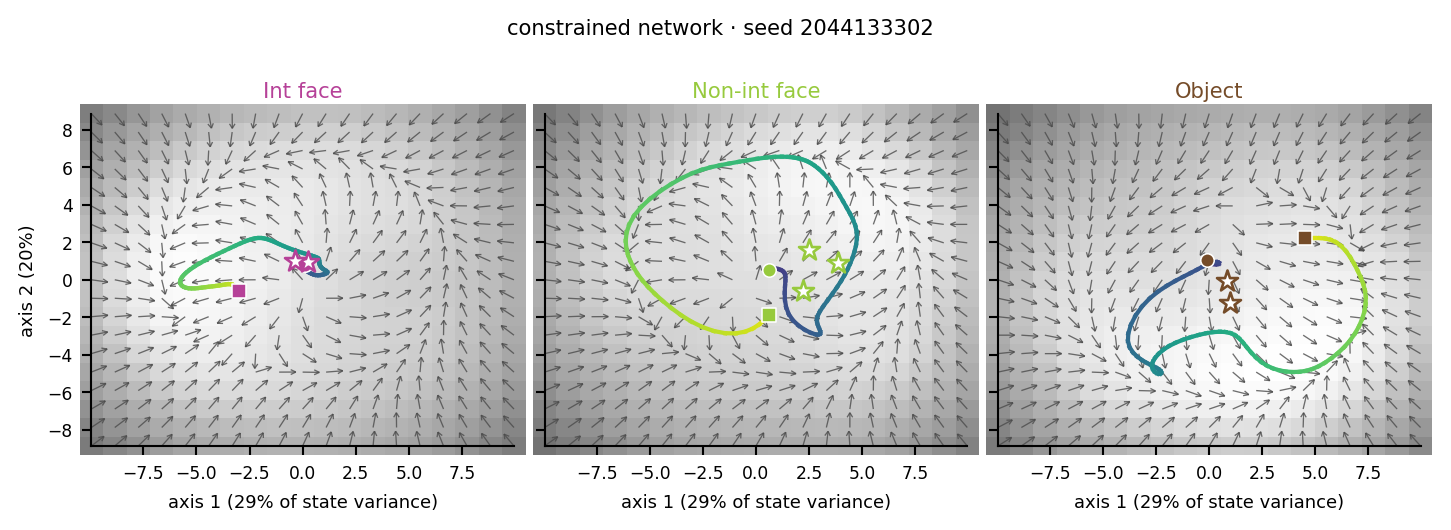

**Figure 9 (constrained). The flow of each fixation type's map, one fit.** Each panel is the autonomous map for one fixation type in the plane of the two leading principal axes of the pooled hidden-state trajectories (the same plane in all three; the percentages are the share of hidden-state variance on each axis). Background: the speed of the flow, $\|F_c(h) - h\|$, log scale, light is slow. Arrows: the direction of the flow projected into the plane. Line: the trajectory the network runs, from the first bin of the window (circle, 495 ms before fixation onset, the trained initial state) to the last (square, 495 ms after), light to dark in time. Stars: fixed points of the map, filled if stable. Nothing is averaged over time; the map is the same at every bin.

In [11]:
for arm, path in ARMS.items():
    run_dir = next(d for d in audit.seed_run_dirs(path) if ens.seed_of(d) == representative[arm])
    fields = ens.flow_fields(run_dir, scope="network")
    figure(eviz.plot_flow_fields(fields, title=f"{arm} network · seed {representative[arm]}"), f"fig09_flow_fields_{arm}",
           f"**Figure 9 ({arm}). The flow of each fixation type's map, one fit.** Each panel is the autonomous map for one fixation "
           "type in the plane of the two leading principal axes of the pooled hidden-state trajectories (the same plane in all three; "
           "the percentages are the share of hidden-state variance on each axis). Background: the speed of the flow, $\\|F_c(h) - h\\|$, "
           "log scale, light is slow. Arrows: the direction of the flow projected into the plane. Line: the trajectory the network runs, "
           "from the first bin of the window (circle, 495 ms before fixation onset, the trained initial state) to the last (square, "
           "495 ms after), light to dark in time. Stars: fixed points of the map, filled if stable. Nothing is averaged over time; the "
           "map is the same at every bin.")

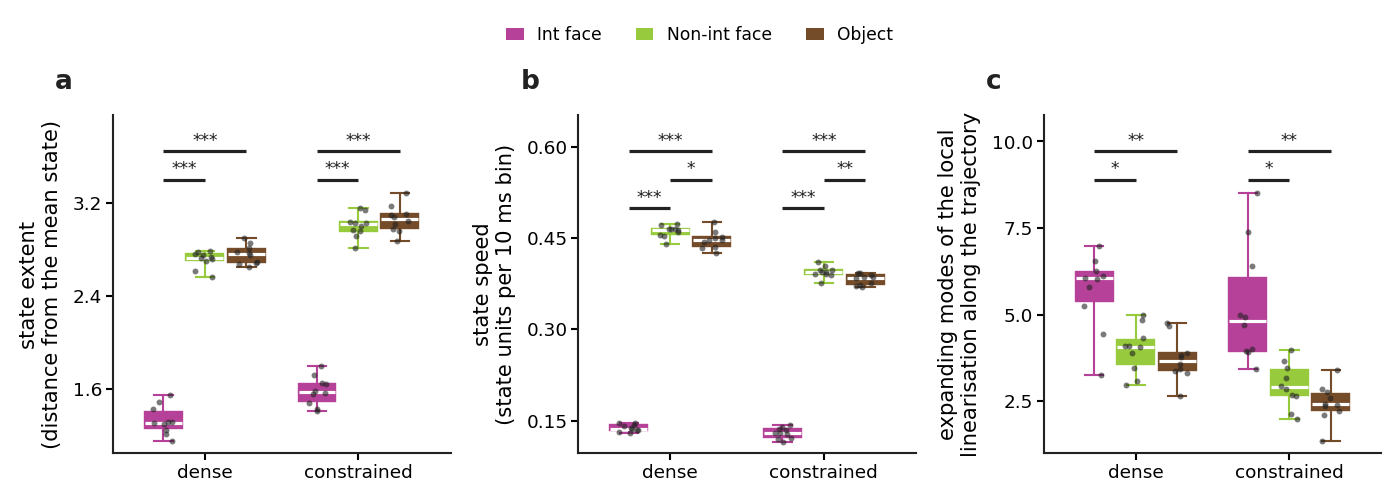

**Figure 10. The interactive-face state, in every fit.** The three fixation types side by side within the dense network (left group) and the constrained network (right group), ten fits per box, every fit a dot: (a) extent of the state trajectory; (b) its speed; (c) number of locally expanding modes of the linearisation along the trajectory. Marks: paired t between fixation types within an arm, Holm-corrected within each panel; only significant contrasts are marked. The remaining per-fixation-type quantities (dimensionality, speed at the end of the window, distance to the nearest fixed point) are in the table below and the §3.10 scoreboard.

**In how many of the ten fits is interactive face the extreme?**

,arm,constrained,dense
property,extreme,,
end of window → nearest fixed point (state extents),lowest,0.7,0.7
expanding modes of the local linearisation along the trajectory,highest,1.0,0.9
speed at the end of the window,lowest,1.0,1.0
state dimensionality (participation ratio),lowest,1.0,1.0
state extent (distance from the mean state),lowest,1.0,1.0
state speed (state units per 10 ms bin),lowest,1.0,1.0


**Means per fixation type** (over fits):

condition                                       Int face  Non-int face  Object
property                           arm                                        
cross_energy_fraction              constrained     0.964         0.954   0.958
                                   dense           0.656         0.685   0.691
n_fixed_points                     constrained     1.700         2.800   2.500
                                   dense           1.400         2.000   2.000
nearest_distance_to_trajectory_end constrained     0.401         0.749   0.763
                                   dense           0.470         0.753   0.888
network_n_expanding                constrained     5.217         2.948   2.441
                                   dense           5.668         3.976   3.723
network_top_modulus                constrained     1.040         1.034   1.031
                                   dense           1.024         1.033   1.033
region_top_modulus                 constrained     0.276         0.251   0.249
                                   dense           0.660         0.624   0.620
state_extent                       constrained     1.582         3.006   3.061
                                   dense           1.330         2.715   2.757
state_pr                           constrained     1.840         3.375   3.361
                                   dense           2.073         4.534   4.414
state_speed                        constrained     0.129         0.394   0.382
                                   dense           0.138         0.461   0.447
trajectory_end_speed               constrained     0.134         0.389   0.413
                                   dense           0.172         0.557   0.620

Fixed points found across both arms: **124**, of which **8** are stable; the rest are saddles with largest |eigenvalue| 1.042–1.106 (interquartile range).

**Tests behind Figure 10 and the other per-fixation-type quantities** (significant contrasts):

,property,arm,a,b,n,difference,statistic,p,p_holm,stars
0,state_extent,constrained,Int face,Non-int face,10,-1.42338,-49.78761,0.00000,0.00000,***
1,state_extent,constrained,Int face,Object,10,-1.47906,-42.44056,0.00000,0.00000,***
3,state_extent,dense,Int face,Non-int face,10,-1.38469,-30.34159,0.00000,0.00000,***
4,state_extent,dense,Int face,Object,10,-1.42718,-26.33016,0.00000,0.00000,***
6,state_speed,constrained,Int face,Non-int face,10,-0.26496,-75.26389,0.00000,0.00000,***
7,state_speed,constrained,Int face,Object,10,-0.25257,-83.47884,0.00000,0.00000,***
8,state_speed,constrained,Non-int face,Object,10,0.01239,3.90883,0.00357,0.00714,**
9,state_speed,dense,Int face,Non-int face,10,-0.32336,-127.44819,0.00000,0.00000,***
10,state_speed,dense,Int face,Object,10,-0.30929,-85.70189,0.00000,0.00000,***
11,state_speed,dense,Non-int face,Object,10,0.01407,3.22459,0.01041,0.01041,*


In [12]:
dyn = ch.dynamics_condition_table(T)
dyn_props = list(cviz.DYNAMICS_LABELS)
dyn_tests = pd.concat([ch.paired_contrasts(dyn[dyn["property"] == p], value="value", by="arm").assign(property=p) for p in dyn_props],
                      ignore_index=True)
figure(cviz.plot_dynamics_summary(dyn, dyn_tests), "fig10_dynamics_summary",
       "**Figure 10. The interactive-face state, in every fit.** The three fixation types side by side within the dense network "
       "(left group) and the constrained network (right group), ten fits per box, every fit a dot: (a) extent of the state "
       "trajectory; (b) its speed; (c) number of locally expanding modes of the linearisation along the trajectory. Marks: paired t "
       "between fixation types within an arm, Holm-corrected within each panel; only significant contrasts are marked. The remaining "
       "per-fixation-type quantities (dimensionality, speed at the end of the window, distance to the nearest fixed point) are in the "
       "table below and the §3.10 scoreboard.")
checks = [("state_extent", "lowest"), ("state_speed", "lowest"), ("state_pr", "lowest"), ("trajectory_end_speed", "lowest"),
          ("nearest_distance_to_trajectory_end", "lowest"), ("network_n_expanding", "highest")]
board = pd.concat([ch.ordering_fraction(dyn, prop=p, extreme=e) for p, e in checks], ignore_index=True)
board["property"] = board["property"].map(lambda p: cviz.DYNAMICS_LABELS.get(p, p).replace("\n", " "))
md("**In how many of the ten fits is interactive face the extreme?**")
display(board.pivot(index=["property", "extreme"], columns="arm", values="fraction").round(2))
md("**Means per fixation type** (over fits):")
display(dyn.groupby(["property", "arm", "condition"])["value"].mean().unstack("condition").rename(columns=COND).round(3))
fp = T["fixed_points_points"]
md(f"Fixed points found across both arms: **{len(fp)}**, of which **{int(fp['stable'].sum())}** are stable; the rest are saddles "
   f"with largest |eigenvalue| {fp['top_modulus'].quantile(0.25):.3f}–{fp['top_modulus'].quantile(0.75):.3f} (interquartile range).")
md("**Tests behind Figure 10 and the other per-fixation-type quantities** (significant contrasts):")
show_tests(dyn_tests[dyn_tests["significant"]], ["property", "arm", "a", "b", "n", "difference", "statistic", "p", "p_holm", "stars"])

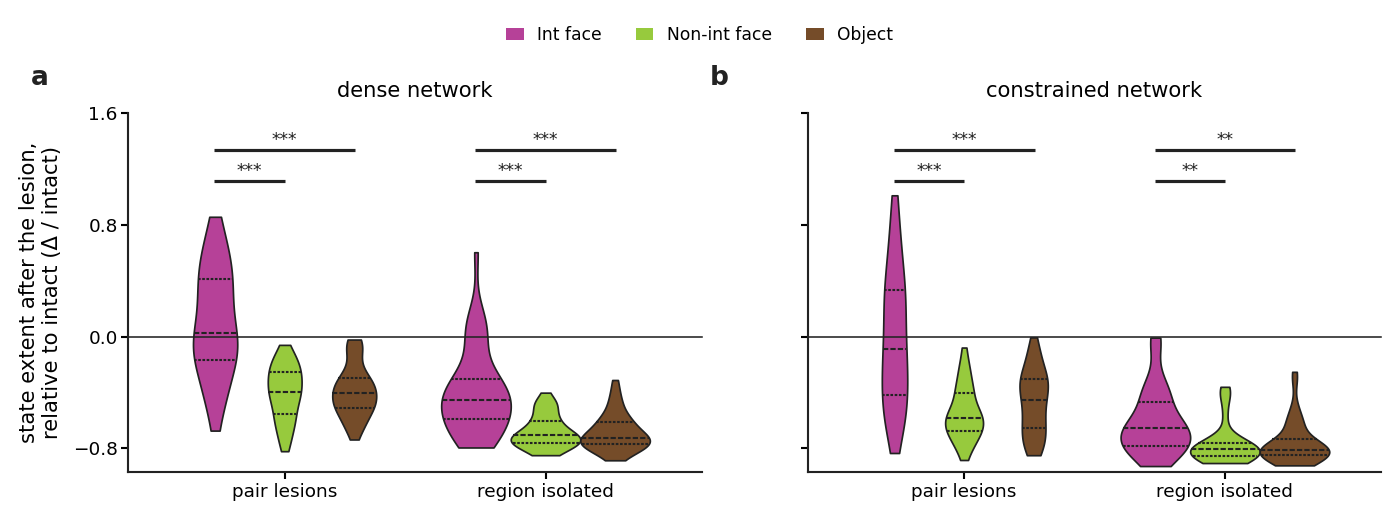

**Figure 11. A pair lesion shrinks the other two trajectories and leaves interactive face's where it is.** Change in the extent of the lesioned network's trajectory relative to the intact one, per fixation type, for every pair lesion (60 values per violin: ten fits × six pairs) and every isolation (40: ten fits × four areas), in the dense (a) and constrained (b) arms; the lines inside each violin are the quartiles (median dashed), and the violins end at the data range. Marks: paired t between fixation types by fit × lesion, Holm-corrected within each panel; only significant contrasts are marked.

**Relative change in state extent after a lesion** (mean, min and max over fits and lesions of that kind):

mean    min    max
arm         lesion_kind   condition                        
constrained bidirectional Int face     -0.006 -0.835  1.013
                          Non-int face -0.543 -0.885 -0.079
                          Object       -0.466 -0.851 -0.006
            isolation     Int face     -0.610 -0.928 -0.008
                          Non-int face -0.768 -0.907 -0.360
                          Object       -0.761 -0.923 -0.253
dense       bidirectional Int face      0.103 -0.674  0.859
                          Non-int face -0.402 -0.822 -0.060
                          Object       -0.389 -0.738 -0.021
            isolation     Int face     -0.395 -0.795  0.605
                          Non-int face -0.680 -0.851 -0.402
                          Object       -0.685 -0.887 -0.312

Fraction of fits in which interactive face's trajectory is the *least* changed by pair lesions: **constrained** 1.0, **dense** 1.0.

**Tests behind Figure 11:**

,arm,lesion_kind,a,b,n,difference,statistic,p,p_holm,stars
0,dense,bidirectional,Int face,Non-int face,60,0.50510,8.82453,0.00000,0.00000,***
1,dense,bidirectional,Int face,Object,60,0.49220,9.18721,0.00000,0.00000,***
2,dense,bidirectional,Non-int face,Object,60,-0.01290,-0.37908,0.70599,1.00000,
3,dense,isolation,Int face,Non-int face,40,0.28586,5.47408,0.00000,0.00001,***
4,dense,isolation,Int face,Object,40,0.28996,5.87519,0.00000,0.00000,***
5,dense,isolation,Non-int face,Object,40,0.00410,0.16017,0.87357,1.00000,
6,constrained,bidirectional,Int face,Non-int face,60,0.53728,9.56007,0.00000,0.00000,***
7,constrained,bidirectional,Int face,Object,60,0.46018,7.55622,0.00000,0.00000,***
8,constrained,bidirectional,Non-int face,Object,60,-0.07711,-2.26809,0.02700,0.05400,
9,constrained,isolation,Int face,Non-int face,40,0.15845,3.71283,0.00064,0.00256,**


In [13]:
lesion_extent = ch.lesion_extent_change(T["lesion_dynamics"])
lesion_extent["unit"] = lesion_extent["seed"].astype(str) + "|" + lesion_extent["lesion"]
extent_tests = pd.concat([ch.paired_contrasts(lesion_extent[lesion_extent["arm"] == arm], value="rel_state_extent", unit="unit", by=["arm", "lesion_kind"])
                          for arm in ARMS], ignore_index=True)
figure(cviz.plot_lesion_extent_violins(lesion_extent, extent_tests), "fig11_lesion_extent",
       "**Figure 11. A pair lesion shrinks the other two trajectories and leaves interactive face's where it is.** Change in the "
       "extent of the lesioned network's trajectory relative to the intact one, per fixation type, for every pair lesion (60 values "
       "per violin: ten fits × six pairs) and every isolation (40: ten fits × four areas), in the dense (a) and constrained (b) arms; "
       "the lines inside each violin are the quartiles (median dashed), and the violins end at the data range. Marks: paired t between "
       "fixation types by fit × lesion, Holm-corrected within each panel; only significant contrasts are marked.")
ext = lesion_extent.groupby(["arm", "lesion_kind", "condition"])["rel_state_extent"].agg(["mean", "min", "max"]).rename(index=COND, level="condition")
md("**Relative change in state extent after a lesion** (mean, min and max over fits and lesions of that kind):")
display(ext.round(3))
least = (lesion_extent[lesion_extent["lesion_kind"] == "bidirectional"].groupby(["arm", "seed", "condition"])["rel_state_extent"].mean()
         .unstack("condition").abs().idxmin(axis=1) == "face_interactive").groupby(level="arm").mean()
md("Fraction of fits in which interactive face's trajectory is the *least* changed by pair lesions: " + ", ".join(f"**{a}** {v:.1f}" for a, v in least.items()) + ".")
md("**Tests behind Figure 11:**")
show_tests(extent_tests, ["arm", "lesion_kind", "a", "b", "n", "difference", "statistic", "p", "p_holm", "stars"])

**The dynamics in the window are transient.** Of 124 fixed points found across the twenty
fits, eight are stable; the rest are saddles with largest eigenvalue modulus a few percent
above one. No trajectory reaches a fixed point within the window: at the last bin every
state is still moving and sits 0.4–0.9 state extents from the nearest fixed point. The
fixed points organise the flow the trajectory passes through — in Figure 9 the trajectories
bend around the hollow stars — but they do not terminate it. A one-second window around a
fixation is not long enough for these networks to settle, and the data they were fitted to
do not settle either.

**Interactive face is the fixation type nearest that organisation, in every fit
(Figure 10).** Its trajectory is the smallest (extent 1.3–1.6 against 2.7–3.1 for the other
two) and the slowest (speed 0.13 against 0.38–0.46 state units per bin) in ten of ten fits
of both arms, and it runs through the most locally expansive part of the flow: the
linearisation along its trajectory has the most expanding modes in ten of ten constrained
and nine of ten dense fits. Each of those contrasts is significant against both other
fixation types in both arms. The quantities not drawn say the same (table above and
§3.10): it is the lowest-dimensional trajectory (participation ratio 1.8–2.1 against
3.4–4.5) and ends the window moving slowest in ten of ten fits, both significant in both
arms, and it ends nearest a fixed point in seven of ten constrained and seven of nine dense
fits (not significant; one dense fit found no fixed point for it). In the flow fields it is
the small loop beside the fixed points, against the wide excursions of the other two
fixation types.

**A lesion separates it further (Figure 11).** Cutting a pair of areas shrinks the trajectories of
non-interactive face and object — by 40–55% of their intact extent on average, and in every
fit × pair case of both arms without exception — and leaves interactive face's on average
unchanged: expanded in about half of the fit × pair cases, shrunk in the rest, and the least
affected of the three fixation types in every fit; the difference from both other fixation
types is significant in both arms, for pair lesions and for isolations. Isolating an area
shrinks all three, interactive face least. The inter-regional traffic, then, does two
different things for the two kinds of fixation: for non-interactive face and object it
drives the state *out* into a large excursion; for interactive face it is as often holding
the state *in* as pushing it out — which is what a state kept small and slow near a saddle
by its inputs would look like.

**What holds and what does not.** The scale-carrying contrasts — extent, speed,
dimensionality — are properties of the data that any adequate fit must reproduce (the
target-side control in the rebuild's audit shows the same ordering in the PC trajectories
themselves). The scale-free ones are the model's own: the count of expanding modes, the
end-of-window speed relative to the nearest fixed point, and the sign of a lesion's effect
on extent. Those are the claims Figures 9–11 add to the population chapter's description of
the interactive-face state as compact and low-dimensional: it is also slow, poised near a
saddle, and held there by the other areas.

### 3.10 Consistency across the ten fits, and what the fits do not agree on

Task 03 keeps two full scoreboards — for every per-fixation-type quantity, the fraction of
fits in which interactive face is the extreme and the separation between fixation types
relative to the seed spread; and for every property, whether the two face fixations are the
closest pair. The summary is displayed below for the record. The fits agree on everything
that is a property of the interactive-face *state* and on nothing that is a property of the
*wiring*: the share of a region's drive that arrives from the network, the alignment of
incoming and own drive, the fixed-point count, the lesion totals and every lesion ranking
are all at chance or at their untrained floor (task 03, §8: every agreement measure of the
rebuild's identifiability battery is at or below its untrained-architecture floor in both
arms).

In [14]:
board = T["ordering_consistency"]
keep = ["r2_vs_ceiling", "state_extent", "state_speed", "state_pr", "drive_pr", "trajectory_end_speed", "nearest_distance_to_trajectory_end",
        "network_n_expanding", "cross_fraction_modulation", "cross_energy_fraction", "alignment", "n_fixed_points", "pair_damage_total", "isolation_damage_total"]
labels = {"r2_vs_ceiling": "fit (R² / ceiling)", "state_extent": "state extent", "state_speed": "state speed", "state_pr": "state dimensionality",
          "drive_pr": "drive dimensionality", "trajectory_end_speed": "speed at end of window", "nearest_distance_to_trajectory_end": "distance to nearest fixed point",
          "network_n_expanding": "expanding modes along trajectory", "cross_fraction_modulation": "within-trial sd of network's share of drive",
          "cross_energy_fraction": "network's share of a region's drive", "alignment": "alignment(incoming, own drive)", "n_fixed_points": "fixed points found",
          "pair_damage_total": "total pair-lesion damage", "isolation_damage_total": "total isolation damage"}
table = board[board["property"].isin(keep)].copy()
table["property"] = pd.Categorical(table["property"].map(labels), categories=[labels[k] for k in keep], ordered=True)
md("**Ordering scoreboard.** Fraction of fits in which interactive face is the lowest / highest, and the separation between fixation types "
   "relative to the seed spread (above 1: the fixation types are further apart than the fits are from one another):")
display(table.sort_values(["property", "arm"]).set_index(["property", "arm"])[["n_fits", "fi_lowest", "fi_highest", "separation"]].round(2))
sim = T["similarity_summary"]
sim_keep = ["target", "state", "cross_share", "lesion_profile", "lesion_ranking_bidirectional", "fixed_point_distance"]
sim_labels = {"target": "data (PC trajectories)", "state": "hidden state", "cross_share": "network's share of drive (time course)",
              "lesion_profile": "lesion-damage profile", "lesion_ranking_bidirectional": "pair-lesion ranking", "fixed_point_distance": "fixed-point distance"}
sim_table = sim[sim["property"].isin(sim_keep)].copy()
sim_table["property"] = pd.Categorical(sim_table["property"].map(sim_labels), categories=[sim_labels[k] for k in sim_keep], ordered=True)
md("**Similarity scoreboard.** Are the two face fixations the closest pair? Similarity (correlation) or distance for each pair of fixation "
   "types, mean over fits, and the fraction of fits in which interactive and non-interactive face are the closest pair (chance 1/3):")
display(sim_table.sort_values(["property", "arm"]).set_index(["property", "arm"])[["kind", "FI–FN", "FI–OBJ", "FN–OBJ", "fi_fn_closest"]].round(3))

**Ordering scoreboard.** Fraction of fits in which interactive face is the lowest / highest, and the separation between fixation types relative to the seed spread (above 1: the fixation types are further apart than the fits are from one another):

n_fits  fi_lowest  fi_highest  separation
property                                    arm                                                   
fit (R² / ceiling)                          constrained      10       1.00        0.00       10.06
                                            dense            10       1.00        0.00       19.57
state extent                                constrained      10       1.00        0.00       13.11
                                            dense            10       1.00        0.00       15.64
state speed                                 constrained      10       1.00        0.00       29.22
                                            dense            10       1.00        0.00       33.25
state dimensionality                        constrained      10       1.00        0.00        7.48
                                            dense            10       1.00        0.00        8.46
drive dimensionality                        constrained      10       1.00        0.00        5.91
                                            dense            10       1.00        0.00        6.86
speed at end of window                      constrained      10       1.00        0.00        6.02
                                            dense            10       1.00        0.00        8.36
distance to nearest fixed point             constrained      10       0.70        0.00        1.56
                                            dense             9       0.78        0.22        2.29
expanding modes along trajectory            constrained      10       0.00        1.00        2.96
                                            dense            10       0.10        0.90        2.67
within-trial sd of network's share of drive constrained      10       0.90        0.00        2.67
                                            dense            10       1.00        0.00        3.21
network's share of a region's drive         constrained      10       0.10        0.60        1.64
                                            dense            10       0.80        0.10        2.25
alignment(incoming, own drive)              constrained      10       0.60        0.20        1.96
                                            dense            10       0.90        0.00        2.60
fixed points found                          constrained      10       0.70        0.10        1.64
                                            dense            10       0.60        0.40        1.63
total pair-lesion damage                    constrained      10       0.70        0.10        1.65
                                            dense            10       0.70        0.10        2.03
total isolation damage                      constrained      10       0.30        0.50        1.58
                                            dense            10       0.80        0.00        2.14

**Similarity scoreboard.** Are the two face fixations the closest pair? Similarity (correlation) or distance for each pair of fixation types, mean over fits, and the fraction of fits in which interactive and non-interactive face are the closest pair (chance 1/3):

kind  FI–FN  FI–OBJ  FN–OBJ  fi_fn_closest
property                               arm                                                          
data (PC trajectories)                 constrained  similarity  0.218   0.034   0.021          1.000
                                       dense        similarity  0.218   0.034   0.021          1.000
hidden state                           constrained  similarity  0.403  -0.089  -0.165          1.000
                                       dense        similarity  0.494  -0.091  -0.034          1.000
network's share of drive (time course) constrained  similarity  0.160   0.043   0.054          0.500
                                       dense        similarity  0.096   0.026   0.009          0.500
lesion-damage profile                  constrained  similarity  0.436   0.510   0.555          0.200
                                       dense        similarity  0.279   0.358   0.359          0.200
pair-lesion ranking                    constrained  similarity  0.107   0.133  -0.040          0.300
                                       dense        similarity  0.093   0.240  -0.027          0.200
fixed-point distance                   constrained    distance  1.312   1.730   1.741          0.800
                                       dense          distance  1.456   1.652   1.564          0.667

One more result from the similarity board deserves a sentence, because it ties back to the
population chapter. In the data the two face fixations are the closest pair — their PC
trajectories correlate at 0.22 against 0.02–0.03 for the pairs involving object. The
network keeps that ordering in its hidden state in ten of ten fits of both arms, and
amplifies it: the two faces' state trajectories correlate at 0.49 (dense) and 0.40
(constrained), twice the data's value, while the pairs involving object fall to zero or
below. The population chapter found that the two faces share a time-locked dynamic that
neither shares with object; the fitted network reproduces that with a state in which the
two faces are *more* alike than the readout requires, which is what a shared face process
with a context-dependent offset would produce.

---

## 4. Discussion

### 4.1 Summary

The four areas' peri-fixation trajectories are not autonomous products of each area. Every
area fitted alone falls short of its own ceiling, and the shortfall is specific: the slow
envelope of the trajectory is generated within an area, and the fast (10–20 Hz) structure is
generated by the areas together. The connections that carry this are the pathways between
areas, not the recurrence within them — removing the pathways costs eight times what
reducing within-region recurrence to rank one does — and the pathways need about ten
dimensions each while an area's own recurrence can be reduced to one. Every one of these
constraints costs the interactive-face trajectory the most, by a third, and the widening
is significant for each. Yet no particular pair of areas carries it, no pair's share of
the damage differs from one sixth, and the ten fits agree on no aspect of the wiring at
all. What they agree on is a dynamical portrait of the interactive-face state: small, slow,
low-dimensional, threading the most expansive part of the flow, the one fixation type
whose trajectory a pair lesion does not shrink, and the one whose local dynamics a pair
lesion reorganises most.

### 4.2 What "needing the network" means

The ladder is the chapter's central experiment because it asks its question by trying
rather than by lesioning. A lesion of a fitted model says what that particular solution
depends on; a refit under a constraint says whether *any* solution of that kind exists.
The finding that a region alone reproduces the slow envelope but not the fast structure of
its trajectory is therefore a statement about the trajectories: their fast structure is the
kind of signal that, at this width and with a constant input, one recurrent block does not
produce on its own and four coupled blocks do. This is the first result in the thesis about
the fast timescale of the peri-fixation response. The population chapter deliberately made
no claim about it, because 20 ms smoothing correlates the noise at the scale a derivative
probes; the mRNN can, because it is fitted to the average and scored against a split-half
ceiling that discounts exactly that noise, and because the constraint result does not
depend on any single derivative estimate.

The band-resolved result also explains the rank result. A within-region block of rank one
can sustain a slow, one-dimensional drive — the envelope; the inter-regional pathways have
to convey enough dimensions to reconstruct fast structure in a 42-dimensional trajectory,
and ten per pathway, thirty into each area, is what that takes. The two constraints act
independently in the grid because they act on different parts of the trajectory.

### 4.3 Why interactive face

Interactive face is the hardest fixation type in the dense network and pays most under
every constraint. Part of the reason is in the data: it has half the variance of the other
two fixation types, so a fixed absolute error is a larger fraction of it, and the minimax
objective, which optimises exactly this fraction, still cannot pull it level. But the
differential test is made on the *gap* — whether the constraint moved interactive face
further from the others than it sat in the dense fits — and the scale-free ratio of
unexplained variance agrees, so the differential effect is not the variance confound
reappearing. The more informative reading comes from the dynamics: the interactive-face
trajectory is the one the network holds small and slow near a saddle, and holding a state
in place against expansive local dynamics is something the inter-regional traffic does — a
pair lesion releases it, and it is the interactive-face map whose local spectrum a pair
lesion moves furthest (§3.8). A trajectory maintained by traffic loses most when the
traffic is narrowed. This is the mechanistic complement of the population chapter's finding
that the interactive-face state is compact and low-dimensional in every area: compact
because it is held, not because it is inert.

### 4.4 Non-identifiability, and the class of claim the chapter makes

The rebuild's audit is the reason this chapter never reads a weight. Ten fits of the same
architecture on the same data agree about their weights, their spectra and their state
geometry no better than untrained networks do (task 03, §8; every similarity margin at or
below zero in both arms), and the constrained architecture does not change that — a
bottleneck constrains how much passes between areas without pinning down what passes. The
lesion results are the same fact from the other side: every lesion is catastrophic, no
pair is privileged, and the rankings are at chance. A well-fitting mRNN is a hypothesis
generator about routing, not a measurement of it.

The claims the chapter does make are of two kinds that survive this. Constraint costs are
statements about the data — whether trajectories of this kind can be produced under a
stated restriction — and are the same whichever equivalent circuit the optimiser found.
Within-model contrasts are computed inside one fit and compared across fixation types; a
reparameterisation of the network applies to every term of such a contrast and cancels,
and the ten fits show which contrasts are properties of the solution set (extent, speed,
dimensionality, end-of-window speed, expanding modes, the lesion's sign) and which are not
(routing, alignment, fixed-point count, lesion totals). Everything in §3.9 belongs to the
first group.

### 4.5 The objective is part of the result

One caveat should be made explicit. The rebuild (`mrnn_thesis` task 03) fitted the strict
removal of every inter-regional block under its balanced-sum objective, and under that
objective the removal costs *non-interactive* face and object most and interactive face
least — the opposite of every per-fixation-type result in the minimax series. The ordering
of the two kinds of connection is the same under both objectives (deleting the
inter-regional blocks costs about eight times what reducing within-region recurrence to a
diagonal does), so the architectural conclusion is robust; the per-fixation-type
conclusion is not robust to the objective, and the chapter's version of it rests on the
minimax objective's property that all twelve combinations are held to the same standard,
so that a cost to one fixation type is a cost the optimiser could not trade away. Any
statement of the form "constraint X hurts condition Y most" made from a fitted model should
be read with the objective beside it.

### 4.6 Limitations

**In-sample.** Every fit is scored on the trajectories it was trained on. The ceiling
bounds what a fit can legitimately reach, and a constrained model that reaches it has
reproduced the average, but no result here is a prediction of held-out data. The training
code supports fitting the pre-fixation half and rolling the dynamics forward through the
post-fixation half; that experiment has not been run.

**Trial averages.** The model is fitted to condition-averaged trajectories and inherits the
population chapter's caveats: object fixations are pooled over interactive state, so part of
the face–object difference could be context mixing; and the averages are Gaussian-smoothed
at 20 ms, so the 20–50 Hz band is partly the smoothing kernel's tail.

**A finely tuned model.** The lesion results describe the fit, not the brain. A network
whose pooled $R^2$ falls to $-3$ when one of sixteen blocks is silenced is finely tuned in
the way any model with parameters near the number of constraints will be, and the absence
of a privileged pair says as much about that as about the areas.

**Width and rank.** Forty units per area is the narrowest width whose readout cap clears
the ceiling, and rank 10 is one point of a grid that stops at 10. Whether the pathways'
requirement is nearer ten or nearer twenty is not resolved by this grid; what is resolved
is that it is far above one and far above what within-region recurrence needs.

**Few fits.** Five fits per grid configuration and ten per ensemble arm are enough to say
that a contrast holds in every fit and to reject equality where the effect is large, and
not enough to estimate how often a weaker effect would appear. The tests in the figures are
parametric because with five fits a paired rank test cannot reach significance at all; an
unmarked comparison is one that did not reach significance, never one shown to be null.
The consistency fractions in §3.10 should be read as "all" or "not all" rather than as
probabilities.

### 4.7 What the model adds to the description

The previous chapters described the peri-fixation population state in each area; this one
asks what it takes to generate it. The answer has three parts that the description could
not have given. The trajectories require traffic between the areas, and the traffic carries
their fast structure. That traffic is moderately high-dimensional — about ten dimensions per
pathway — while each area's own dynamics can be nearly one-dimensional. And the fixation
type whose state the population chapter singled out as compact and low-dimensional is the
one the traffic serves most and the one it holds in place: a slow state near a saddle,
maintained by the network rather than generated by any area. Which pathway does the holding
is not a question these data answer, and the chapter's claim is pitched accordingly, at the
level of what the areas must exchange and what the exchange does, rather than at the level
of a circuit.

---

## Appendix: where each result lives

| Chapter figure | Task notebook | What the task notebook adds |
|---|---|---|
| 1, 1b | — | schematics; the bottleneck schematic in `02b` §1 defines every drive quantity |
| 2, 3 | `01_ladder` | every region's fit gallery, the partner matrix, band recovery per region, the per-combination heatmap |
| 4 | `01_ladder`, `02_rank_grid`; `../mrnn_thesis/03_connectivity` | the rebuild's strict removals, directed and pair cuts under its own objective |
| 5 | `02_rank_grid` | convergence of every configuration, the adequacy table, the selection rule |
| 6 | `02b_bottleneck_properties` | the condition gap along each marginal, region heatmaps, where a region's drive comes from, alignment and dimensionality |
| 7 | `03_ensemble` §3 | loss curves, every combination of both arms, reconstruction galleries of all ten fits, bootstrap intervals |
| 8 | `03_ensemble` §7 | every lesion family per arm, per-target damage, per-fixation-type rankings, lesion-profile similarity |
| 8b–8e | this notebook (`final/04_chapter/tables/lesion_region_spectra*.csv`) | eigenvalue spectra of the lesioned linearisations and their Wasserstein distances, region and network scope |
| 9–11 | `03_ensemble` §5–7 | drive and flow, per-region flow fields, fixed-point summaries, Jacobians along the trajectory, region timescales, lesioned dynamics on speed, modulus and dimensionality |
| §3.10 | `03_ensemble` §4, §8–9 | the similarity boards per property and region; the identifiability battery against the untrained floor |

The rebuild series (`../mrnn_thesis/`) holds the protocol sweep, the capacity analysis, the
audit that fixed the ceiling, the damage units and the agreement measures, and the
solution-manifold argument this chapter's framing rests on.